In [308]:
import os
from pathlib import Path
import json
from typing import List, Tuple, Dict, Optional, Sequence, Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.linalg import lstsq
from scipy.signal import butter, filtfilt, medfilt, welch
from scipy.stats import skew, kurtosis
from scipy.stats import entropy as _entropy
from scipy.stats import pointbiserialr

from sklearn.model_selection import GroupKFold, StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit

from __future__ import annotations

# ONNX export
try:
    import onnx   # noqa: F401
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
except Exception:
    convert_sklearn = None

## 1. Configs & Visualization Utils
1.1. Configs

In [ ]:
# CONFIGS

DATASET_DIR = "./UCI HAR Dataset/UCI HAR Dataset"
PROJECT_ROOT = Path.cwd().parent       # HARSYS/
DATA_ROOT = PROJECT_ROOT / "data"      # HARSYS/data
# NOTE "GENERAL" mode requires at least 3 subjects ! (for train/test/val)
MODE        = "per_person"     # "general" or "per_person"
SPLIT_MODE  = "block"     # or "block" (for individual person)
PERSON      = "veronica"          # or "paul", etc.

LABEL_NAME_TO_ID = {
    "stand": 0,
    "sit":   1,
    "walk":  2,
    "turn":  3,
}
STAND_ID = LABEL_NAME_TO_ID["stand"]
SIT_ID   = LABEL_NAME_TO_ID["sit"]
WALK_ID  = LABEL_NAME_TO_ID["walk"]
TURN_ID  = LABEL_NAME_TO_ID["turn"]

ACTIVITY_ORDER_BASE = ["stand", "walk", "sit", "turn"]

STATIC_CLASSES = ["stand", "sit"]
DYNAMIC_CLASSES = ["walk", "turn"]

# Separate SVM 1 and 0 class mappings (binary)
STATIC_PAIR_POS = {STAND_ID}   # stand = 1
STATIC_PAIR_NEG = {SIT_ID}     # sit   = 0

DYNAMIC_PAIR_POS = {WALK_ID}   # walk  = 1
DYNAMIC_PAIR_NEG = {TURN_ID}   # turn  = 0

STATIC_LABELS = {
    0: "Sit",
    1: "Stand",
}

DYN_LABELS = {
    0: "Turn",
    1: "Walk",
}

FS    = 119.0   # Hz (CLI overridable)
WIN   = 200     # samples (CLI)
HOP   = 100     # samples (CLI) 50% overlap
GUARD = 50      # samples trimmed from each block edge (CLI)
NUM_AXES = 3    # triaxial signal

AR_ORDER = 4
SEED      = 13 # Reproducibility

1.2. Data Visualization (Plotting Utils)

In [310]:
sns.set_context("notebook")
sns.set_style("whitegrid")

ACTIVITY_LABELS = {
    "stand": "Standing",
    "sit":   "Sitting",
    "walk":  "Walking",
    "turn":  "Turning",
}

LABEL_ID_TO_DISPLAY = {
    LABEL_NAME_TO_ID[name]: pretty
    for name, pretty in ACTIVITY_LABELS.items()
}

STATIC_IDS  = {LABEL_NAME_TO_ID["stand"], LABEL_NAME_TO_ID["sit"]}
DYNAMIC_IDS = {LABEL_NAME_TO_ID["walk"],  LABEL_NAME_TO_ID["turn"]}

def to_intensity_labels(y_4class: np.ndarray) -> np.ndarray:
    """
    Map 4-class labels to binary intensity labels:
      0 = static   (stand, sit)
      1 = dynamic  (walk, turn)
    """
    y_4class = np.asarray(y_4class)
    return np.where(np.isin(y_4class, list(DYNAMIC_IDS)), 1, 0)

# Color palette per class (string key = raw label)
PALETTE = {
    "stand": "#914FAF",
    "sit":   "#F394C0",
    "walk":  "#5AB5E6",
    "turn":  "#FFB347",
}

RAW_COLOR = "#503EDC"

INTENSITY_LABELS = {
    0: "Static (sit/stand)",
    1: "Dynamic (walk/turn)",
}

# reuse colors from main PALETTE
INTENSITY_PALETTE = {
    0: PALETTE["sit"],   # static
    1: PALETTE["walk"],  # dynamic
}

def _intensity_to_display(c: int) -> str:
    return INTENSITY_LABELS.get(int(c), str(int(c)))


def _label_to_display(c, activity_map=ACTIVITY_LABELS):
    """Helper: map raw label (str/int) to display name."""
    return activity_map.get(c, str(c))

def _make_hue_palette(y_raw, activity_map=ACTIVITY_LABELS, palette=PALETTE):
    """
    y_raw: array of raw labels (e.g., 'stand','sit','walk','turn')
    Returns:
      hue_palette: {pretty_label -> color}
      disp: list of pretty labels
    """
    y_raw = np.asarray(y_raw)
    labs = np.unique(y_raw)
    disp = [_label_to_display(c, activity_map) for c in labs]
    cols = [palette.get(c, RAW_COLOR) for c in labs]
    return dict(zip(disp, cols)), disp


# 1) After initial loading: activity histogram (all 4 classes)
def plot_activity_histogram(y_ids,
                            activity_map=ACTIVITY_LABELS,
                            title="Raw Training Set: Activity Histograms",
                            color: str = RAW_COLOR,
                            top_pad: float = 0.12,
                            x_pad: float = 0.02):
    """
    y_ids: array-like of raw labels ("stand", "sit", "walk", "turn") or ints;
           activity_map maps them to pretty names.
    """
    y_ids = np.asarray(y_ids)
    ids, counts = np.unique(y_ids, return_counts=True)
    names = [_label_to_display(i, activity_map) for i in ids]

    order = np.argsort(counts)[::-1]
    counts_ord = counts[order]
    names_ord  = np.array(names)[order]

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(x=names_ord, y=counts_ord, color=color, ax=ax)

    ymax = counts_ord.max()
    ax.set_ylim(0, ymax * (1 + top_pad))
    ax.margins(x=x_pad)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

    ax.set_ylabel("Windows")
    ax.set_xlabel("Activity")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()


# 2) Single-split class balance (any label array, 4 classes)
def plot_class_balance(y,
                       activity_map=ACTIVITY_LABELS,
                       palette=PALETTE,
                       title="Class balance"):
    """
    y: array-like of raw labels ("stand", "sit", "walk", "turn" or subset).
    """
    y = np.asarray(y)
    labs, counts = np.unique(y, return_counts=True)
    names  = [_label_to_display(c, activity_map) for c in labs]
    colors = [palette.get(c, RAW_COLOR) for c in labs]

    plt.figure(figsize=(5, 4))
    sns.barplot(x=names, y=counts, palette=colors)
    for i, v in enumerate(counts):
        plt.text(i, v*1.01, str(v), ha="center", va="bottom", fontsize=9)
    plt.ylabel("Windows")
    plt.xlabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 3) After 65 / 20 / 15 split: side-by-side class balance (train/val/test)
def plot_split_balance(y_tr,
                       y_val,
                       y_test=None,
                       activity_map=ACTIVITY_LABELS,
                       palette=PALETTE,
                       title: str = "Class balance by split (65/20/15)",
                       top_pad: float = 0.12,
                       x_pad: float = 0.02):
    """
    y_tr, y_val, y_test: arrays of raw labels ("stand", "sit", "walk", "turn").
    For your project, typically:
      - y_tr : ~65% of data
      - y_val: ~20%
      - y_test: ~15% (held-out)
    """
    frames = [("Train (65%)", y_tr), ("Validation (20%)", y_val)]
    if y_test is not None:
        frames.append(("Test (15%)", y_test))

    rows = []
    for split_name, y_split in frames:
        y_split = np.asarray(y_split)
        labs, counts = np.unique(y_split, return_counts=True)
        for c, n in zip(labs, counts):
            rows.append({
                "Split": split_name,
                "Class": _label_to_display(c, activity_map),
                "Windows": int(n),
            })

    df = pd.DataFrame(rows)

    # Build hue palette based on classes actually present
    all_raw = np.concatenate([
        np.asarray(y_tr),
        np.asarray(y_val),
        np.asarray(y_test) if y_test is not None else np.array([], dtype=object)
    ])
    hue_palette, hue_order = _make_hue_palette(all_raw,
                                               activity_map=activity_map,
                                               palette=palette)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=df,
                x="Split", y="Windows",
                hue="Class",
                hue_order=sorted(hue_order),
                palette=hue_palette,
                ax=ax)

    heights = [p.get_height() for p in ax.patches if p.get_height() is not None]
    if heights:
        ax.set_ylim(0, max(heights) * (1 + top_pad))
    ax.margins(x=x_pad)

    for container in ax.containers:
        if hasattr(container, "datavalues"):
            ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

    ax.set_title(title)
    ax.set_ylabel("Windows")
    ax.set_xlabel("")
    ax.legend(title="Class")
    fig.tight_layout()
    plt.show()

# ======================= FEATURE ENGINEERING PLOTS ===========================
# “Feature vs label” scatter/box overlay (e.g., energy vs class)
def plot_feature_vs_label(X: np.ndarray, y: np.ndarray,
                          feature_names: Sequence[str],
                          feature_name: str,
                          activity_map=ACTIVITY_LABELS,
                          palette=PALETTE,
                          title: Optional[str] = None):
    """
    X: (n_samples, n_features)
    y: labels ("stand", "sit", "walk", "turn")
    feature_name: name of a single feature to plot vs class
    """
    y = np.asarray(y)
    idx = feature_names.index(feature_name)
    df = pd.DataFrame({
        feature_name: X[:, idx],
        "Class": [_label_to_display(c, activity_map) for c in y],
    })

    hue_palette, hue_order = _make_hue_palette(y, activity_map=activity_map, palette=palette)
    hue_order = sorted(hue_order)

    plt.figure(figsize=(5.8, 4))
    sns.stripplot(data=df,
                  x="Class", y=feature_name,
                  order=hue_order,
                  jitter=0.25,
                  palette=hue_palette,
                  alpha=0.6)
    sns.boxplot(data=df,
                x="Class", y=feature_name,
                order=hue_order,
                showcaps=True,
                boxprops={'facecolor': 'none'},
                showfliers=False,
                whiskerprops={'linewidth': 1},
                width=0.4)
    plt.title(title or f"{feature_name} vs Class")
    plt.tight_layout()
    plt.show()

def plot_feature_by_class(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    feature: str,
    activity_map=ACTIVITY_LABELS,
    palette=PALETTE,
    kind: str = "violin",
    title: str | None = None,
):
    if feature not in colnames:
        raise ValueError(f"{feature} not found in colnames.")
    idx = colnames.index(feature)

    y = np.asarray(y)
    df = pd.DataFrame({
        "value": Xf[:, idx],
        "Class": [_label_to_display(c, activity_map) for c in y],
    })

    # Build palette from raw labels y
    hue_palette, hue_order = _make_hue_palette(y,
                                               activity_map=activity_map,
                                               palette=palette)
    hue_order = sorted(hue_order)

    plt.figure(figsize=(6, 4))
    if kind == "box":
        sns.boxplot(data=df, x="Class", y="value",
                    order=hue_order,
                    palette=hue_palette)
    else:
        sns.violinplot(data=df, x="Class", y="value",
                       order=hue_order,
                       inner="quartile", cut=0, scale="width",
                       palette=hue_palette)
    plt.title(title or f"{feature} per class")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

def plot_features_grid_by_class(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    features: List[str],
    activity_map=ACTIVITY_LABELS,
    palette=PALETTE,
    kind: str = "violin",
    ncols: int = 3,
    suptitle: str | None = None,
):
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    y = np.asarray(y)
    df = pd.DataFrame({
        "Class": [_label_to_display(c, activity_map) for c in y]
    })
    for f in features:
        df[f] = Xf[:, colnames.index(f)]

    # Palette / order from raw labels
    hue_palette, hue_order = _make_hue_palette(y,
                                               activity_map=activity_map,
                                               palette=palette)
    hue_order = sorted(hue_order)

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(data=df, x="Class", y=fname,
                        order=hue_order,
                        palette=hue_palette,
                        ax=ax)
        else:
            sns.violinplot(data=df, x="Class", y=fname,
                           order=hue_order,
                           inner="quartile", cut=0, scale="width",
                           palette=hue_palette,
                           ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


def feature_corr_heatmap(
    Xf: np.ndarray,
    colnames: List[str],
    title: str = "Feature correlation (Pearson)",
):
    corr = pd.DataFrame(Xf, columns=colnames).corr()
    size = min(1 + 0.25 * len(colnames), 14)
    plt.figure(figsize=(size, min(size, 10)))
    sns.heatmap(corr, cmap="vlag", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Correlation ratio η²: "how much of feature variance is explained by class?" ----
def correlation_ratio_table(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: list[str],
) -> pd.DataFrame:
    """
    Compute correlation ratio η²(feature, class) for each feature.

    η² = SB / ST in ANOVA terms:
      SB = between-class sum of squares
      ST = total sum of squares

    Range ~ [0,1]. Higher = stronger dependence on class.
    Works for any number of classes.
    """
    Xf = np.asarray(Xf, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    n_features = Xf.shape[1]

    rows = []
    eps = 1e-12

    for j in range(n_features):
        f = Xf[:, j]
        mu = f.mean()
        ST = np.sum((f - mu) ** 2) + eps  # total variance * N

        SB = 0.0
        for c in classes:
            f_c = f[y == c]
            if f_c.size == 0:
                continue
            n_c = f_c.size
            mu_c = f_c.mean()
            SB += n_c * (mu_c - mu) ** 2

        eta2 = SB / ST
        rows.append((colnames[j], eta2))

    tb = (pd.DataFrame(rows, columns=["feature", "eta2"])
            .sort_values("eta2", ascending=False))
    return tb

def plot_feature_class_effects(
    eta_table: pd.DataFrame,
    top_k: int = 20,
    title: str = r"Feature–class effect sizes ($\eta^2$)",
):
    """
    Barplot of top-k features by correlation ratio η².
    eta_table: output of correlation_ratio_table(...)
    """
    tb = eta_table.copy()
    tb = tb.nlargest(top_k, "eta2")

    plt.figure(figsize=(8, 0.35 * len(tb)))
    sns.barplot(data=tb, x="eta2", y="feature", orient="h")
    plt.xlabel(r"Correlation ratio $\eta^2$ (variance explained by class)")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ======================= END FEATURE ENGINEERING PLOTS =======================

# ======== Class-wise summary stats ===========
def classwise_stats(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    activity_map=ACTIVITY_LABELS,
):
    """
    Returns (mean_df, median_df) per class (rows = pretty class names).
    Works for any number of classes.
    """
    y = np.asarray(y)
    df = pd.DataFrame(Xf, columns=colnames)
    df["Class"] = [_label_to_display(c, activity_map) for c in y]

    g = df.groupby("Class")
    out_mean = g.mean()
    out_med  = g.median()
    return out_mean, out_med

def fisher_scores(Xf, y, colnames):
    y = np.asarray(y)
    scores = []
    for i in range(Xf.shape[1]):
        f0 = Xf[y==0, i]; f1 = Xf[y==1, i]
        num = (np.mean(f1) - np.mean(f0))**2
        den = np.var(f1) + np.var(f0) + 1e-12
        scores.append(num/den)
    fs = pd.Series(scores, index=colnames).sort_values(ascending=False)
    return fs

def point_biserial_table(Xf, y, colnames):
    vals = []
    for i, name in enumerate(colnames):
        r, p = pointbiserialr(y, Xf[:, i])
        vals.append((name, r, p))
    tb = pd.DataFrame(vals, columns=["feature","r_pb","p_value"]).sort_values("r_pb", ascending=False)
    return tb

# ======================= INTENSITY (STATIC vs DYNAMIC) PLOTS =======================

def plot_intensity_feature(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    colnames: List[str],
    feature: str,
    kind: str = "violin",
    title: str | None = None,
):
    """
    Single-feature distribution for the intensity pre-classifier:

      - y_4class: 4-class window labels (0..3 or label IDs)
      - Internally mapped to:
            0 = Static (sit/stand)
            1 = Dynamic (walk/turn)

    kind: "violin" or "box"
    """
    if feature not in colnames:
        raise ValueError(f"{feature} not found in colnames.")
    idx = colnames.index(feature)

    # map 4-class -> intensity 0/1
    y_int = to_intensity_labels(y_4class)
    y_int = np.asarray(y_int)

    df = pd.DataFrame({
        "value": Xf[:, idx],
        "Intensity": [_intensity_to_display(c) for c in y_int],
    })

    order = [_intensity_to_display(0), _intensity_to_display(1)]
    palette = [INTENSITY_PALETTE[0], INTENSITY_PALETTE[1]]

    plt.figure(figsize=(5.8, 4))
    if kind == "box":
        sns.boxplot(
            data=df,
            x="Intensity",
            y="value",
            order=order,
            palette=palette,
        )
    else:
        sns.violinplot(
            data=df,
            x="Intensity",
            y="value",
            order=order,
            inner="quartile",
            cut=0,
            scale="width",
            palette=palette,
        )

    plt.xlabel("")
    plt.ylabel(feature)
    plt.title(title or f"{feature} — Static vs Dynamic")
    plt.tight_layout()
    plt.show()


def plot_intensity_features_grid(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    colnames: List[str],
    features: List[str],
    kind: str = "violin",
    ncols: int = 3,
    suptitle: str | None = "Pre-classifier features — Static vs Dynamic",
):
    """
    Grid of violin/box plots for the intensity pre-classifier.

      - y_4class: 4-class window labels
      - Internally mapped to:
            0 = Static (sit/stand)
            1 = Dynamic (walk/turn)
    """
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    y_int = to_intensity_labels(y_4class)
    y_int = np.asarray(y_int)

    df = pd.DataFrame({
        "Intensity": [_intensity_to_display(c) for c in y_int]
    })
    for f in features:
        df[f] = Xf[:, colnames.index(f)]

    order = [_intensity_to_display(0), _intensity_to_display(1)]
    palette = [INTENSITY_PALETTE[0], INTENSITY_PALETTE[1]]

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(
                data=df,
                x="Intensity",
                y=fname,
                order=order,
                palette=palette,
                ax=ax,
            )
        else:
            sns.violinplot(
                data=df,
                x="Intensity",
                y=fname,
                order=order,
                inner="quartile",
                cut=0,
                scale="width",
                palette=palette,
                ax=ax,
            )
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()

# ======================= END INTENSITY PLOTS =======================

def plot_pair_features_grid(
    X_pair: np.ndarray,
    y_pair_4class: np.ndarray,
    colnames: list[str],
    features: list[str],
    kind: str = "violin",
    ncols: int = 2,
    suptitle: str | None = None,
):
    """
    Grid of violin/box plots for a *pairwise* activity SVM:
      - X_pair:  (n_samples, n_features_subset)  (can be selected cols)
      - y_pair_4class: original 4-class integer labels (0..3) for these samples
      - colnames: names of the columns in X_pair
      - features: which features (by name) to plot (subset of colnames)

    Uses LABEL_ID_TO_DISPLAY to show nice class names:
      Sitting vs Standing, or Walking vs Turning.
    """
    y_pair_4class = np.asarray(y_pair_4class)

    # sanity: ensure all requested features exist in colnames
    missing = [f for f in features if f not in colnames]
    if missing:
        raise ValueError(f"Missing features in colnames: {missing}")

    # map 4-class IDs -> pretty names ("Sitting", "Standing", ...)
    class_names = [LABEL_ID_TO_DISPLAY[int(c)] for c in y_pair_4class]

    df = pd.DataFrame({"Class": class_names})
    for fname in features:
        j = colnames.index(fname)
        df[fname] = X_pair[:, j]

    n = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.3 * ncols, 3.4 * nrows),
        squeeze=False
    )
    axes = axes.ravel()

    for ax, fname in zip(axes, features):
        if kind == "box":
            sns.boxplot(data=df, x="Class", y=fname, ax=ax)
        else:
            sns.violinplot(
                data=df, x="Class", y=fname,
                inner="quartile", cut=0, scale="width",
                ax=ax,
            )
        ax.set_xlabel("")
        ax.set_ylabel(fname)

    # turn off any unused subplots
    for j in range(len(features), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()



## 2. Data Loading & Segmentation

2.1. Window Class & Associated Window Building Functions 

In [311]:
# ========== window class ==========

class Window:
    def __init__(self):
        # Sequential index for bookkeeping (1,2,3,...)
        self.seq: int = 0
        # Flat window content: [x1,y1,z1, x2,y2,z2, ..., xL,yL,zL]
        self.window_arr: Optional[np.ndarray] = None
        # Raw label for this window (e.g., "stand", "sit", "walk", "turn" or an int code)
        self.window_label: Any = None
        # Optional metadata (useful for grouping later by subject or block)
        self.subject_id: Optional[str] = None
        self.block_id: Optional[int] = None
        self.block_uid: Optional[str] = None
        # Output of feature extraction:
        # By convention we store a tuple: (feature_vector: np.ndarray, feature_dict: Dict[str, float])
        self.features: Optional[Tuple[np.ndarray, Dict[str, float]]] = None

# ========== helpers: flat window <-> axes ==========

def split_xyz_from_flat(raw_flat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    raw_flat = [x1,y1,z1, x2,y2,z2, ...]  -> returns (x[], y[], z[]) each length L.
    Assumes 3 channels (x,y,z) in that order.
    """
    return raw_flat[0::3], raw_flat[1::3], raw_flat[2::3]

def flat_from_xyz_block(xyz_block: np.ndarray) -> np.ndarray:
    """
    xyz_block shape (L,3) -> flat [x1,y1,z1, x2,y2,z2, ...] in row-major order.
    """
    assert xyz_block.ndim == 2 and xyz_block.shape[1] == 3, "xyz_block must be [L,3]"
    return xyz_block.reshape(-1)

# helper to check if window is 'pure' (all same label)
def is_good_window(y: np.ndarray, startIdx: int, window_len_samples: int) -> bool:
    """
    Returns True if all samples from start_idx to start_idx+window_len_samples
    have the same label.
    """
    if startIdx + window_len_samples > y.size:
        return False
    block_y = y[startIdx:startIdx+window_len_samples]
    if np.all(block_y == block_y[0]):
        return True
    else:
        return False


# ========== core window builder ==========

def window_builder(
    X: np.ndarray,               # [N,3] (x,y,z) samples over time
    y: np.ndarray,               # [N] per-sample labels (e.g., "stand"/"sit"/"walk"/"turn")
    window_len_samples: int = 128,
    window_hop_samples: int = 64,
    fs: float = 119.0, # Hz
    feature_func: Optional[
        Callable[[np.ndarray, np.ndarray, np.ndarray, float],
                 Tuple[np.ndarray, Dict[str, float]]]
    ] = None,
    require_pure_windows: bool = True,
    subject_id: Optional[str] = None,
    block_id: Optional[int] = None,
    block_uid: Optional[str] = None,
) -> Tuple[List[Window], Dict[Any, List[Window]]]:
    """
    Slide a fixed-length window over a [N,3] accelerometer stream and build Window objects.

    Parameters
    ----------
    X : np.ndarray
        Shape [N,3], columns = x,y,z samples.
    y : np.ndarray
        Shape [N], per-sample labels. Can be strings ("stand", "sit", ...) or ints.
    window_len_samples : int
        Number of time samples per window (e.g., 128).
    window_hop_samples : int
        Hop size in samples (e.g., 64 for 50% overlap).
    fs : float
        Sampling frequency in Hz (used for feature extraction).
    feature_func : callable or None
        If provided, will be called as:
            feature_func(x_window, y_window, z_window, fs)
        and must return (feature_vector, feature_dict).
        Example:
            fv: 1D np.ndarray
            feature_dict: {"skewness": ..., "bp_0p5_3": ..., ...}
    require_pure_windows : bool
        If True, only accept windows where all y samples are the same.
        If False, windows may span label boundaries (should be on for calib).
    subject_id, block_id, block_uid :
        Optional metadata to tag each Window (for per-person/block-aware pipelines).

    Returns
    -------
    windows : List[Window]
        All constructed window objects (in time order).
    by_label : Dict[label, List[Window]]
        Mapping from label value to list of Window objects.
        Label keys are whatever type y[start_idx] has (str or int).
    """
    assert X.ndim == 2 and X.shape[1] == 3, "X must be [N,3]"
    assert y.ndim == 1 and y.shape[0] == X.shape[0], "y must match X rows"

    N = X.shape[0]
    window_len_raw = window_len_samples * NUM_AXES

    windows: List[Window] = []
    by_label: Dict[Any, List[Window]] = {}

    win_count = 0
    start_index = 0

    while True:
        # Stop if we don't have enough samples left for a full window
        if start_index + window_len_samples > N:
            break

        # Optionally enforce that this window stays inside a single class
        if require_pure_windows and not is_good_window(y, start_index, window_len_samples):
            # bad window (spans multiple labels) -> shift by 1 sample and try again
            start_index += 1
            continue

        # Build window
        win = Window()
        win.window_arr = np.empty(window_len_raw, dtype=float)

        # Copy samples [start_index : start_index+window_len_samples] from X into flat buffer
        end_index = start_index + window_len_samples
        segment = X[start_index:end_index, :]  # shape [L,3]
        win.window_arr[:] = flat_from_xyz_block(segment)

        win.window_label = y[start_index]     # all samples in window share this if pure
        win.seq = win_count + 1
        win_count += 1

        win.subject_id = subject_id
        win.block_id = block_id
        win.block_uid = block_uid

        # Feature computation if func provided
        if feature_func is not None:
            xw, yw, zw = split_xyz_from_flat(win.window_arr)
            fv, fv_dict = feature_func(xw, yw, zw, fs)
            win.features = (np.asarray(fv, dtype=float), dict(fv_dict))

        windows.append(win)
        by_label.setdefault(win.window_label, []).append(win)

        # Move forward by hop
        start_index += window_hop_samples

    return windows, by_label


# ========== stack features into a matrix ==========

def stack_features(windows: List[Window]) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Stack per-window features into a design matrix.

    Assumes each Window has:
        win.features = (feature_vec, feature_dict)
    with identical keys in feature_dict for all windows.

    Returns
    -------
    Xf : np.ndarray
        Shape [n_windows, n_features]
    yf : np.ndarray
        Shape [n_windows], labels (same type as window.window_label)
    colnames : List[str]
        Feature names in the same order as Xf columns.
    """
    usable = [w for w in windows if w.features is not None]
    if not usable:
        raise ValueError("No window has features. Make sure feature_func is provided to window_builder().")

    # Reference ordering of features from the first window
    _, first_dict = usable[0].features
    colnames = list(first_dict.keys())

    # Stack feature vectors in that order
    rows = []
    labels = []
    for w in usable:
        fv, fd = w.features
        # Rebuild row using dict order to be safe
        rows.append([fd[k] for k in colnames])
        labels.append(w.window_label)

    Xf = np.asarray(rows, dtype=float)
    yf = np.asarray(labels, dtype=object)

    return Xf, yf, colnames

2.2. Data Loading, Cleaning, Splitting & Visualization
- Define label mapping
- Builds contiguous windows from training blocks (when active == 1) and assigns their labels based on activity_order
- Does a group aware 65/20/15 split
- Handles mode "general" and mode "per-person" by splitting by subject IDs (general = no subject leakage) or block UIDs (per-person = no block leakage)
- Plots histograms & split balances to assess data

In [312]:
# ---------- Block helpers ----------

def find_active_blocks(active: np.ndarray) -> list[tuple[int, int]]:
    """
    Find contiguous runs where active == 1.
    Returns list of (start, end) indices with end exclusive.
    """
    blocks: list[tuple[int, int]] = []
    in_run = False
    start = 0
    for idx, val in enumerate(active):
        if val == 1 and not in_run:
            in_run = True
            start = idx
        elif val == 0 and in_run:
            blocks.append((start, idx))
            in_run = False
    if in_run:
        blocks.append((start, len(active)))
    return blocks


def _rotate_activity_order(start_activity: str | None) -> list[str]:
    """
    Rotate ACTIVITY_ORDER_BASE so that the first label is start_activity (if provided).
    """
    if not start_activity:
        return ACTIVITY_ORDER_BASE.copy()
    if start_activity not in ACTIVITY_ORDER_BASE:
        raise ValueError(f"start_activity='{start_activity}' not in {ACTIVITY_ORDER_BASE}")
    idx = ACTIVITY_ORDER_BASE.index(start_activity)
    return ACTIVITY_ORDER_BASE[idx:] + ACTIVITY_ORDER_BASE[:idx]


def assign_labels_to_blocks(
    n_samples: int,
    blocks: list[tuple[int, int]],
    order: list[str],
) -> np.ndarray:
    """
    Given active blocks and an activity order, assign activity names to each sample
    inside active segments. Inactive (rest) samples get "".
    """
    labels = np.array([""] * n_samples, dtype=object)
    for k, (a, b) in enumerate(blocks):
        cls_name = order[k % len(order)]
        labels[a:b] = cls_name
    return labels


# ---------- Group-aware 65 / 20 / 15 split ----------
# This is generic group-awareness: will pass in groups by subject_id per window or block_uid per window based on mode.
def _groupwise_train_val_test_split(
    y: np.ndarray,
    groups: np.ndarray,
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    65 / 20 / 15 split with group awareness (no group leakage).
    Uses GroupShuffleSplit twice:
      1) train vs temp
      2) temp -> val vs test
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, "Fractions must sum to 1."

    y = np.asarray(y)
    groups = np.asarray(groups)

    # 1) train vs temp
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_frac, random_state=seed)
    train_idx, temp_idx = next(gss1.split(X=np.zeros_like(y), y=y, groups=groups))

    # 2) val vs test on temp
    temp_y = y[temp_idx]
    temp_groups = groups[temp_idx]
    rel_val = val_frac / (val_frac + test_frac)

    gss2 = GroupShuffleSplit(n_splits=1, train_size=rel_val, random_state=seed + 1)
    val_rel_idx, test_rel_idx = next(
        gss2.split(X=np.zeros_like(temp_y), y=temp_y, groups=temp_groups)
    )
    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]

    return train_idx, val_idx, test_idx

def _stratified_train_val_test_split(
    y: np.ndarray,
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    65 / 20 / 15 split with *label stratification* (no grouping).
    Used for mode='per_person', so each split sees all 4 classes
    in similar proportions.
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    y = np.asarray(y)
    sss1 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=train_frac,
        random_state=seed,
    )
    train_idx, temp_idx = next(sss1.split(X=np.zeros_like(y), y=y))

    temp_y = y[temp_idx]
    rel_val = val_frac / (val_frac + test_frac)

    sss2 = StratifiedShuffleSplit(
        n_splits=1,
        train_size=rel_val,
        random_state=seed + 1,
    )
    val_rel_idx, test_rel_idx = next(sss2.split(X=np.zeros_like(temp_y), y=temp_y))

    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]

    return train_idx, val_idx, test_idx


# ---------- Build windows from ONE calib CSV ----------

def _windows_from_calib_file(
    csv_path: Path,
    fs: float,
    win_len_samples: int,
    win_hop_samples: int,
    guard_samples: int,
    start_activity: str | None,
    subject_id: str | None = None,
) -> list[Window]:
    """
    For a single calibration CSV with columns: tick, x, y, z, active
    - Find active blocks (active == 1)
    - Assign activity labels to each sample inside blocks in a fixed order
      (e.g., stand -> walk -> sit -> turn -> repeat)
    - Trim guard_samples from block edges
    - Build sliding windows (Window objects) via window_builder
    """
    df = pd.read_csv(csv_path)
    for col in ["x", "y", "z", "active"]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {csv_path}")

    x = df["x"].to_numpy(dtype=float)
    y = df["y"].to_numpy(dtype=float)
    z = df["z"].to_numpy(dtype=float)
    active = df["active"].astype(int).to_numpy()
    N = len(active)

    # If not provided, fall back to file stem (old behavior)
    if subject_id is None:
        subject_id = csv_path.stem

    blocks = find_active_blocks(active)
    if not blocks:
        print(f"[WARN] No active blocks in {csv_path}")
        return []

    order = _rotate_activity_order(start_activity)
    labels_str = assign_labels_to_blocks(N, blocks, order=order)

    windows: list[Window] = []

    for block_id, (a, b) in enumerate(blocks):
        lab_str = labels_str[a]
        if lab_str == "":
            continue
        if lab_str not in LABEL_NAME_TO_ID:
            continue

        class_id = LABEL_NAME_TO_ID[lab_str]

        # Trim guard samples to avoid transition jitter
        s = a + guard_samples
        e = b - guard_samples
        if e - s < win_len_samples:
            continue

        X_seg = np.column_stack([x[s:e], y[s:e], z[s:e]])   # [L,3]
        y_seg = np.full(e - s, class_id, dtype=int)         # all same label

        block_uid = f"{subject_id}#blk{block_id}"

        # Build windows on this segment (no features yet)
        seg_windows, _ = window_builder(
            X_seg,
            y_seg,
            window_len_samples=win_len_samples,
            window_hop_samples=win_hop_samples,
            fs=fs,
            feature_func=None,
            require_pure_windows=True,
            subject_id=subject_id,
            block_id=block_id,
            block_uid=block_uid,
        )
        windows.extend(seg_windows)

    return windows


# ---------- Top-level loader: general vs per-person ----------

def load_calib_windows_for_svm(
    mode: str = "general",              # "general" or "per_person"
    data_root: str = "data",           # base folder
    person: str | None = None,         # required if mode == "per_person"
    fs: float = FS,
    win_len_samples: int = WIN,
    win_hop_samples: int = HOP,
    guard_samples: int = GUARD,
    start_activity: str | None = "stand",
    train_frac: float = 0.65,
    val_frac: float = 0.20,
    test_frac: float = 0.15,
    seed: int = SEED,
):
    """
    - mode="general":
        data_root/*.csv each correspond to one subject (by filename stem).
    - mode="per_person":
        data_root/<person>/*.csv all belong to the same person.

    Returns
    -------
    windows : list[Window]
        All window objects (no features yet).
    y_all : np.ndarray
        Window-level class IDs (0..3) in the same order as `windows`.
    groups : np.ndarray
        For general mode: subject IDs (per window).
        For per_person mode: block_uids (per window).
    idx_tr, idx_val, idx_test : np.ndarray
        Indices into `windows` / `y_all` for the 65/20/15 split.
    """
    data_root_path = Path(data_root)

    # --- Collect windows ---
    windows: list[Window] = []

    if mode == "per_person":
        if person is None:
            raise ValueError("mode='per_person' requires `person`.")
        base = data_root_path / person
        csvs = sorted(base.glob("*.csv"))
        if not csvs:
            FileNotFoundError(f"No CSVs found for person '{person}' in {base}")
        print(f"[MODE] Per-person: {person}")
        for csv_path in csvs:
            w = _windows_from_calib_file(
                csv_path=csv_path,
                fs=fs,
                win_len_samples=win_len_samples,
                win_hop_samples=win_hop_samples,
                guard_samples=guard_samples,
                start_activity=start_activity,
                subject_id=person,   # <-- NEW: consistent subject_id
            )
            print(f"[LOAD:{person}] {csv_path.name}: {len(w)} windows")
            windows.extend(w)


    elif mode == "general":
        # Look for per-person subfolders under data_root
        person_dirs = [d for d in data_root_path.iterdir() if d.is_dir()]
        if not person_dirs:
            raise FileNotFoundError(
                f"No subject folders found in {data_root_path} "
                "(expected data_root/<person>/*.csv)"
            )
        person_dirs = sorted(person_dirs)
        print(f"[MODE] General (multi-subject). Subject folders in {data_root_path}: {len(person_dirs)}")
        for person_dir in person_dirs:
            person_id = person_dir.name
            csvs = sorted(person_dir.glob("*.csv"))
            if not csvs:
                print(f"[WARN] No CSVs found for subject '{person_id}' in {person_dir}, skipping.")
                continue
            for csv_path in csvs:
                w = _windows_from_calib_file(
                    csv_path=csv_path,
                    fs=fs,
                    win_len_samples=win_len_samples,
                    win_hop_samples=win_hop_samples,
                    guard_samples=guard_samples,
                    start_activity=start_activity,
                    subject_id=person_id,
                )
                print(f"[LOAD:{person_id}] {csv_path.name}: {len(w)} windows")
                windows.extend(w)

    else:
        raise ValueError(f"Unknown mode '{mode}' (use 'general' or 'per_person').")

    if not windows:
        raise RuntimeError("No windows constructed; check data_root, files, and active blocks.")

    # --- Build y and groups arrays ---
    y_all = np.asarray([w.window_label for w in windows], dtype=int)

    if mode == "general":
        groups = np.asarray([w.subject_id for w in windows], dtype=object)
    else:
        groups = np.asarray([w.block_uid for w in windows], dtype=object)

    # --- Plot overall histogram before splitting ---
    def _activity_map_for_plot():
        # map 0,1,2,3 -> "Standing", "Sitting", ...
        return {k: v for k, v in LABEL_ID_TO_DISPLAY.items()}

    plot_activity_histogram(
        y_ids=y_all,
        activity_map=_activity_map_for_plot(),
        title=f"Raw window set: activity histogram ({mode})",
    )

    # --- Group-aware 65/20/15 split ---
    if mode == "general":
        # multi-subject: avoid subject leakage (group = subject_id)
        idx_tr, idx_val, idx_te = _groupwise_train_val_test_split(
            y=y_all,
            groups=groups,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            seed=seed,
        )
    else:
        # per_person: stratified by 4-class labels at window level
        idx_tr, idx_val, idx_te = _stratified_train_val_test_split(
            y=y_all,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            seed=seed,
        )

    y_tr, y_val, y_te = y_all[idx_tr], y_all[idx_val], y_all[idx_te]
    print("All windows label counts:", dict(zip(*np.unique(y_all, return_counts=True))))
    print("TRAIN label counts:",      dict(zip(*np.unique(y_tr,  return_counts=True))))
    print("VAL label counts:",        dict(zip(*np.unique(y_val, return_counts=True))))
    print("TEST label counts:",       dict(zip(*np.unique(y_te,  return_counts=True))))


    plot_split_balance(
        y_tr,
        y_val,
        y_te,
        title=f"Class balance by split ({mode})",
    )

    print("Train (65%) counts:", {int(k): int(v) for k, v in zip(*np.unique(y_tr, return_counts=True))})
    print("Valid (20%) counts:", {int(k): int(v) for k, v in zip(*np.unique(y_val, return_counts=True))})
    print("Test (15%) counts:",  {int(k): int(v) for k, v in zip(*np.unique(y_te,  return_counts=True))})

    if mode == "general":
        subs_tr = {windows[i].subject_id for i in idx_tr}
        subs_val = {windows[i].subject_id for i in idx_val}
        subs_te  = {windows[i].subject_id for i in idx_te}
        print("Subject overlap train/val?", len(subs_tr & subs_val) > 0)
        print("Subject overlap train/test?", len(subs_tr & subs_te) > 0)
    else:
        bl_tr = {windows[i].block_uid for i in idx_tr}
        bl_val = {windows[i].block_uid for i in idx_val}
        bl_te  = {windows[i].block_uid for i in idx_te}
        print("Block overlap train/val?", len(bl_tr & bl_val) > 0)
        print("Block overlap train/test?", len(bl_tr & bl_te) > 0)

    return windows, y_all, groups, idx_tr, idx_val, idx_te


# 3. Feature Engineering

## 3.1. Feature Extraction Helpers

In [313]:
def mag_from_xyz(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> np.ndarray:
    return np.sqrt(x*x + y*y + z*z)

def _as_float(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

def mean(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.mean(x))

def std(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.std(x))

def rms(x: np.ndarray) -> float:
    x = _as_float(x);  return float(np.sqrt(np.mean(x*x)))

def mad(x: np.ndarray) -> float:
    x = _as_float(x);  m = np.median(x)
    return float(np.median(np.abs(x - m)))

def iqr(x: np.ndarray) -> float:
    x = _as_float(x)
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)

def axis_corr(a: np.ndarray, b: np.ndarray) -> float:
    a, b = _as_float(a), _as_float(b)
    if a.size < 2 or b.size < 2: return 0.0
    aa, bb = a - a.mean(), b - b.mean()
    sa, sb = aa.std(), bb.std()
    if sa == 0.0 or sb == 0.0: return 0.0
    return float(np.mean(aa*bb) / (sa*sb))

def _welch(sig: np.ndarray, fs: float, nperseg: int = 128) -> Tuple[np.ndarray, np.ndarray]:
    s = _as_float(sig)
    if s.size < 16: return np.array([0.0]), np.array([0.0])
    nps = int(max(16, min(nperseg, s.size)))
    f, P = welch(s, fs=fs, nperseg=nps)
    if not np.any(np.isfinite(P)): return np.array([0.0]), np.array([0.0])
    return f, P

def _bandpower(f: np.ndarray, P: np.ndarray, lo: float, hi: float) -> float:
    m = (f >= lo) & (f < hi)
    if not np.any(m): return 0.0
    return float(np.trapz(P[m], f[m]))

# ===== TIME DOMAIN FEATURES =====
# per-axis stats (x,y,z)
def mean_axis(x,y,z, axis: str) -> float:
    return mean({'x':x, 'y':y, 'z':z}[axis])

def std_axis(x,y,z, axis: str) -> float:
    return std({'x':x, 'y':y, 'z':z}[axis])

def rms_axis(x,y,z, axis: str) -> float:
    return rms({'x':x, 'y':y, 'z':z}[axis])

def mad_axis(x,y,z, axis: str) -> float:
    return mad({'x':x, 'y':y, 'z':z}[axis])

def iqr_axis(x,y,z, axis: str) -> float:
    return iqr({'x':x, 'y':y, 'z':z}[axis])

def _zero_cross_rate(sig: np.ndarray) -> float:
    """
    Zero-crossing rate of a 1D signal.
    """
    s = _as_float(sig)
    if s.size < 2:
        return 0.0
    # remove DC to make sign changes more meaningful
    s = s - s.mean()
    signs = np.sign(s)
    # treat zeros as continuity -> shift to previous non-zero sign
    for i in range(1, signs.size):
        if signs[i] == 0:
            signs[i] = signs[i-1]
    zc = np.count_nonzero(signs[1:] * signs[:-1] < 0)
    return float(zc / (s.size - 1))

# magnitude features
def sma_xyz(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    x, y, z = _as_float(x), _as_float(y), _as_float(z)
    N = max(1, x.size)
    return float((np.sum(np.abs(x)) + np.sum(np.abs(y)) + np.sum(np.abs(z))) / N)

def mean_mag(x,y,z): return mean(mag_from_xyz(x,y,z))
def std_mag(x,y,z):  return std(mag_from_xyz(x,y,z))
def rms_mag(x,y,z):  return rms(mag_from_xyz(x,y,z))
def mad_mag(x,y,z):  return mad(mag_from_xyz(x,y,z))
def iqr_mag(x,y,z):  return iqr(mag_from_xyz(x,y,z))
def ptp_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    """
    Peak-to-peak range of the acceleration magnitude.
    """
    m = _as_float(mag_from_xyz(x, y, z))
    if m.size == 0:
        return 0.0
    return float(m.max() - m.min())
def zcr_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    """
    Zero-crossing rate of the acceleration magnitude.
    (After DC removal, so it behaves like an oscillatory signal.)
    """
    m = _as_float(mag_from_xyz(x, y, z))
    return _zero_cross_rate(m)

# correlations between axes
def xy_corr(x,y,z): return axis_corr(x,y)
def yz_corr(x,y,z): return axis_corr(y,z)
def zx_corr(x,y,z): return axis_corr(z,x)

# CUSTOM FEATURES
# (1) Custom Feature: tilt_variability
# --> describes angle wrt horizontal plane (z) which increases with dynamic motion
# (2) Custom Feature: vertical_acceleration_ratio
# --> describes vertical acceleration (aligned with g) normalized by horizontal components
# --> during dynamic activities -> vertical oscillations dominate (leg push-off, heel strike) hence large vertical_acceleration_ratio value
def vertical_acceleration_ratio(x,y,z):
    psi = np.std(z)/(np.std(x)+np.std(y)+1e-6) # avoid div by 0
    return float(psi)
def tilt_variability(x,y,z):
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    tilt = np.arctan2(z, np.sqrt(x*x + y*y))
    return float(np.std(tilt))

# ===== TIME-FREQUENCY DOMAIN: AR(p) on magnitude =====
def ar_coeffs_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, p: int = 4) -> Tuple[np.ndarray, float]:
    m = _as_float(mag_from_xyz(x,y,z))
    m = m - m.mean()
    if m.size <= p + 2:
        return np.zeros(p, dtype=float), 0.0
    N = m.size
    Y = m[p:]
    X = np.column_stack([m[p - i - 1: N - i - 1] for i in range(p)])
    a, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ a
    return a.astype(float), float(np.var(resid))

# ===== FREQUENCY DOMAIN: PSD / FFT magnitudes =====
_BANDS = {
    "bp_0p5_3":  (0.5, 3.0),   # gait
    "bp_3_8":    (3.0, 8.0),   # stairs / higher harmonics
    "bp_8_15":   (8.0, 15.0),
}

def total_power_mag(x,y,z, fs: float) -> float:
    f, P = _welch(mag_from_xyz(x,y,z), fs)
    if f.size == 1: return 0.0
    return float(np.trapz(P, f))

def bandpowers_mag(x,y,z, fs: float) -> Dict[str, float]:
    f, P = _welch(mag_from_xyz(x,y,z), fs)
    if f.size == 1: return {k: 0.0 for k in _BANDS}
    return {k: _bandpower(f, P, lo, hi) for k, (lo,hi) in _BANDS.items()}

def spectral_entropy_mag(x,y,z, fs: float) -> float:
    f, P = _welch(mag_from_xyz(x,y,z), fs)
    if f.size == 1: return 0.0
    P = np.maximum(P, 1e-12)
    p = P / np.sum(P)
    return float(_entropy(p, base=2.0))  # bits

def spec_centroid_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Spectral centroid (Hz) of the magnitude signal.
    """
    f, P = _welch(mag_from_xyz(x, y, z), fs)
    if f.size <= 1 or not np.any(P > 0):
        return 0.0
    P = np.maximum(P, 1e-12)
    num = np.sum(f * P)
    den = np.sum(P)
    return float(num / den)

def dom_freq_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Dominant frequency (Hz) of the magnitude signal based on PSD peak.
    """
    f, P = _welch(mag_from_xyz(x, y, z), fs)
    if f.size <= 1 or not np.any(P > 0):
        return 0.0
    idx = int(np.argmax(P))
    return float(f[idx])

def spec_bandwidth_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Spectral bandwidth (Hz) around the centroid of the magnitude signal.
    """
    f, P = _welch(mag_from_xyz(x, y, z), fs)
    if f.size <= 1 or not np.any(P > 0):
        return 0.0
    P = np.maximum(P, 1e-12)
    P_sum = np.sum(P)
    centroid = np.sum(f * P) / P_sum
    var = np.sum(((f - centroid) ** 2) * P) / P_sum
    return float(np.sqrt(max(var, 0.0)))

def spec_flatness_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float) -> float:
    """
    Spectral flatness (Wiener entropy) of the magnitude signal.
    = geometric_mean(PSD) / arithmetic_mean(PSD)
    """
    f, P = _welch(mag_from_xyz(x, y, z), fs)
    if f.size <= 1 or not np.any(P > 0):
        return 0.0
    P = np.maximum(P, 1e-12)
    log_gm = np.mean(np.log(P))
    gm = np.exp(log_gm)
    am = np.mean(P)
    return float(gm / am)

# ===== FEATURE REGISTRY =====
# base feature functions that take (x,y,z[,fs]) and return a scalar
FeatureFn = Callable[..., float]
FEATURES: Dict[str, Callable[..., float]] = {
    # magnitude scalars
    "sma_xyz": sma_xyz,
    "mean_mag": mean_mag, "std_mag": std_mag, "rms_mag": rms_mag,
    "mad_mag": mad_mag, "iqr_mag": iqr_mag,
    "xy_corr": xy_corr, "yz_corr": yz_corr, "zx_corr": zx_corr,
    # PSD
    "total_power_mag": total_power_mag,
    "spectral_entropy_mag": spectral_entropy_mag,
    # AR
    "ar_mag_coeffs": ar_coeffs_mag,
    # bandpower expansions are handled in compute_features
    "tilt_variability": tilt_variability,
    "vertical_acceleration_ratio": vertical_acceleration_ratio,
    "ptp_mag": ptp_mag,
    "zcr_mag": zcr_mag,
    "dom_freq_mag": dom_freq_mag,
    "spec_centroid_mag": spec_centroid_mag,
    "spec_bandwidth_mag": spec_bandwidth_mag,
    "spec_flatness_mag": spec_flatness_mag,
}
# per-axis templates -> expand to _x/_y/_z
_PER_AXIS_TEMPLATES = {
    "mean": mean_axis,
    "std": std_axis,
    "rms": rms_axis,
    "mad": mad_axis,
    "iqr": iqr_axis,
}

def compute_features(
    x: np.ndarray, y: np.ndarray, z: np.ndarray, fs: float,
    feature_names: List[str], ar_order: int = 4
) -> Tuple[np.ndarray, Dict[str, float]]:
    """
    Evaluate requested features in order.
    - Per-axis requests can be specified either:
        'mean_axis'  -> expands to mean_x, mean_y, mean_z
      or explicitly as:
        'mean_x', 'std_y', 'rms_z', ...
    - 'ar_mag_coeffs' expands to ar_order coeffs + residual variance.
    - 'bandpowers_mag' expand to multiple outputs.
    Returns (vector, dict of name->value in the same order).
    - Index 0 (vector): 1D NumPy array of the ftr values in a fixed order
    - Index 1 (dict): a {feature_name: value} mapping in the same order the vector was built
    """
    vals: List[float] = []
    out: Dict[str, float] = {}

    def _add(name: str, value: float):
        vals.append(float(value)); out[name] = float(value)

    for name in feature_names:
        # expand templates like "mean_axis" -> x,y,z
        if name.endswith("_axis") and name[:-5] in _PER_AXIS_TEMPLATES:
            base = name[:-5]
            fn = _PER_AXIS_TEMPLATES[base]
            for ax in ("x","y","z"):
                v = fn(x,y,z, ax)
                _add(f"{base}_{ax}", v)
            continue

        # explicit per-axis like "std_x"
        if "_" in name and name.split("_",1)[0] in _PER_AXIS_TEMPLATES and name[-2:] in {"_x","_y","_z"}:
            base, ax = name.split("_",1)
            fn = _PER_AXIS_TEMPLATES[base]
            v = fn(x,y,z, ax)
            _add(name, v)
            continue

        if name == "bandpowers_mag":
            bp = bandpowers_mag(x,y,z,fs)
            for k, v in bp.items():
                _add(k, v)
            continue

        if name == "ar_mag_coeffs":
            a, var = ar_coeffs_mag(x,y,z, p=ar_order)
            for i, c in enumerate(a, 1):
                _add(f"ar{ar_order}_c{i}", c)
            _add(f"ar{ar_order}_resvar", var)
            continue

        # scalar magnitude or correlation or PSD/entropy
        fn = FEATURES[name]
        if fn in {
            total_power_mag,
            spectral_entropy_mag,
            dom_freq_mag,
            spec_centroid_mag,
            spec_bandwidth_mag,
            spec_flatness_mag,
        }:
            v = fn(x, y, z, fs)
        else:
            v = fn(x, y, z)
        _add(name, v)

    return np.asarray(vals, dtype=float), out

def attach_features_to_windows(
    windows,
    fs: float,
    feature_names: list[str],
    ar_order: int = 4,
):
    """
    Mutates each Window in-place:
      - reads w.window_arr (flat [x1,y1,z1,...])
      - computes fv, fv_dict via compute_features(...)
      - stores w.features = (fv, fv_dict)
    """
    for w in windows:
        if w.window_arr is None:
            raise ValueError("Window has no raw data (window_arr is None).")
        xw, yw, zw = split_xyz_from_flat(w.window_arr)
        fv, fv_dict = compute_features(
            xw, yw, zw,
            fs=fs,
            feature_names=feature_names,
            ar_order=ar_order,
        )
        w.features = (fv, fv_dict)


## 3.2. Initial Feature Extraction (All Ftrs)

[MODE] Per-person: veronica
[LOAD:veronica] accel_calib_data_veronica_1.csv: 2574 windows
[LOAD:veronica] accel_calib_data_veronica_2.csv: 3104 windows
[LOAD:veronica] accel_calib_data_veronica_3.csv: 4204 windows


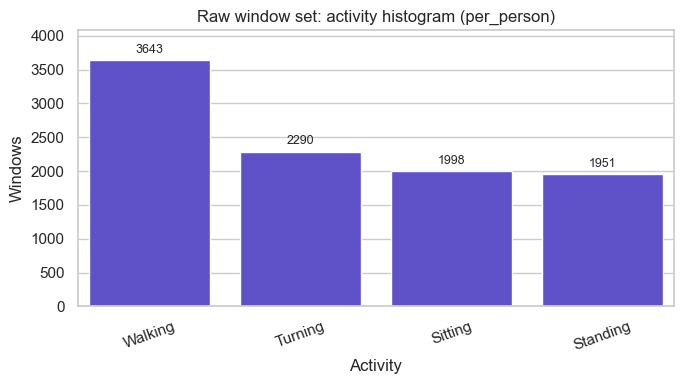

All windows label counts: {np.int64(0): np.int64(1951), np.int64(1): np.int64(1998), np.int64(2): np.int64(3643), np.int64(3): np.int64(2290)}
TRAIN label counts: {np.int64(0): np.int64(1268), np.int64(1): np.int64(1299), np.int64(2): np.int64(2368), np.int64(3): np.int64(1488)}
VAL label counts: {np.int64(0): np.int64(390), np.int64(1): np.int64(399), np.int64(2): np.int64(729), np.int64(3): np.int64(458)}
TEST label counts: {np.int64(0): np.int64(293), np.int64(1): np.int64(300), np.int64(2): np.int64(546), np.int64(3): np.int64(344)}


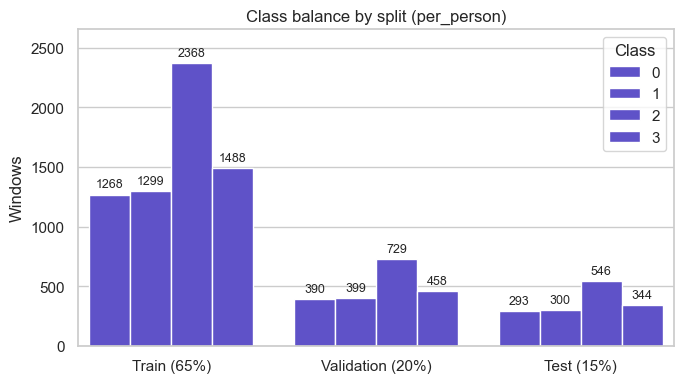

Train (65%) counts: {0: 1268, 1: 1299, 2: 2368, 3: 1488}
Valid (20%) counts: {0: 390, 1: 399, 2: 729, 3: 458}
Test (15%) counts: {0: 293, 1: 300, 2: 546, 3: 344}
Block overlap train/val? True
Block overlap train/test? True
#windows: train=6423, val=1976, test=1483


In [314]:
# ================== 1) LOAD WINDOWS & GROUPWISE SPLIT ==================
windows, y_all, groups, idx_tr, idx_val, idx_te = load_calib_windows_for_svm(
    mode=MODE,
    data_root=DATA_ROOT,
    person=PERSON,
    fs=FS,
    win_len_samples=WIN,
    win_hop_samples=HOP,
    guard_samples=GUARD,
    start_activity="stand",
    train_frac=0.65,
    val_frac=0.20,
    test_frac=0.15,
    seed=SEED,
)

# build window subsets per split
windows_tr  = [windows[i] for i in idx_tr]
windows_val = [windows[i] for i in idx_val]
windows_te  = [windows[i] for i in idx_te]

y_tr  = y_all[idx_tr]
y_val = y_all[idx_val]
y_te  = y_all[idx_te]

print(f"#windows: train={len(windows_tr)}, val={len(windows_val)}, test={len(windows_te)}")

C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\1416324868.py:150: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P, f))
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\1416324868.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(P[m], f[m]))


TRAIN feature matrix: (6423, 42)
VAL   feature matrix: (1976, 42)
TEST  feature matrix: (1483, 42)
TRAIN class-wise means:
             mean_x       mean_y       mean_z        std_x        std_y  \
Class                                                                    
0      3885.155714  1158.140785   387.676045    50.332136    56.174986   
1      5307.402875   559.229557  2883.251647    43.963552    33.302992   
2      5104.449086   625.801981    86.766474  1331.485777  1034.601310   
3      3643.921109   983.686993  -661.521216   681.652291   851.822609   

             std_z        rms_x        rms_y        rms_z       mad_x  ...  \
Class                                                                  ...   
0        57.020528  7428.029485  1900.299975   587.988760   33.191246  ...   
1        35.483972  6118.644661  1087.176402  2884.252406   30.358353  ...   
2      1104.461274  7700.445092  2229.900599  1487.168089  949.756757  ...   
3       507.657004  7442.925476  2589.747

C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Class", y=fname,
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:327: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x="Class", y=fname,
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Class", y=fname,
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:327: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.1

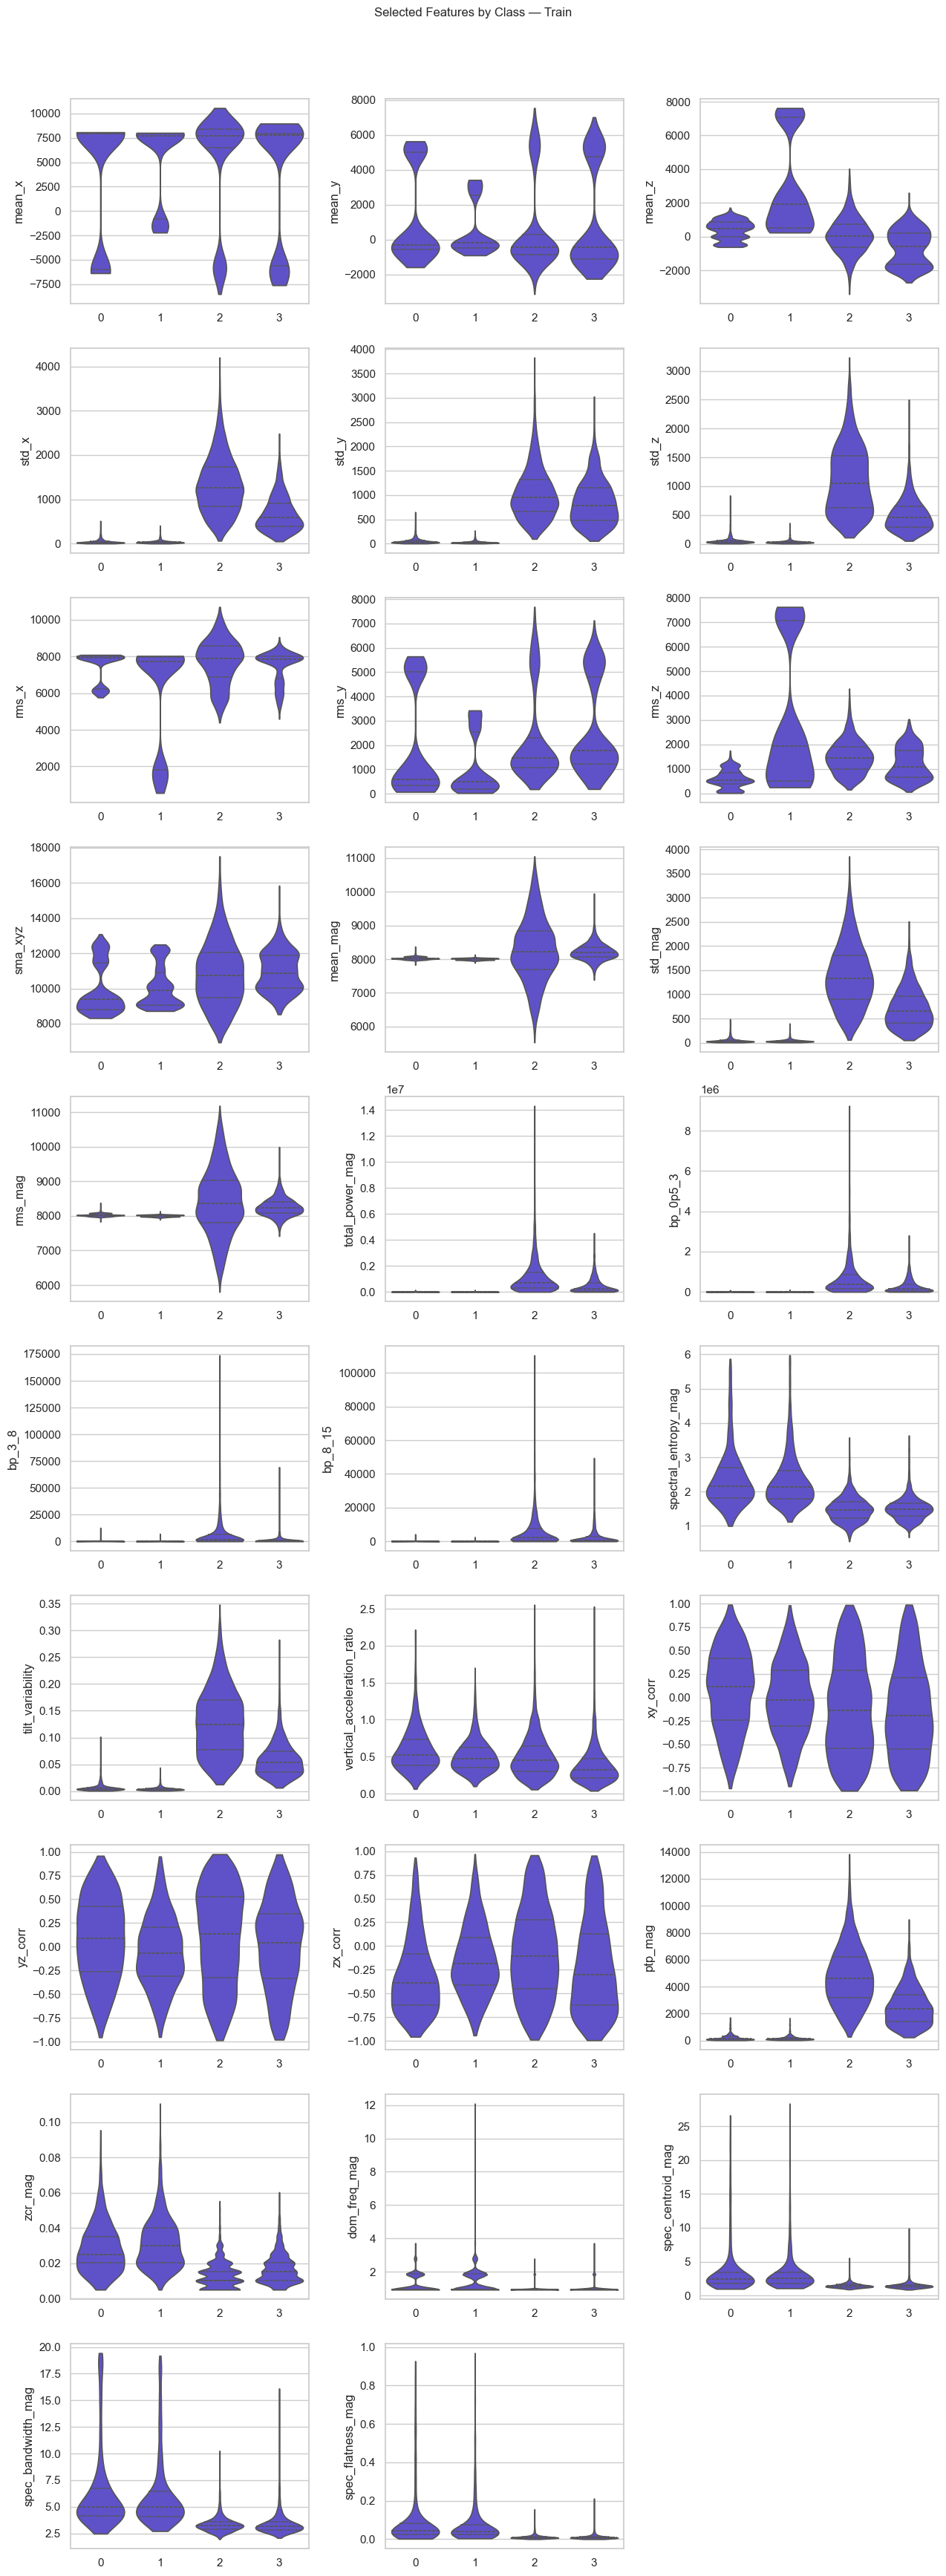

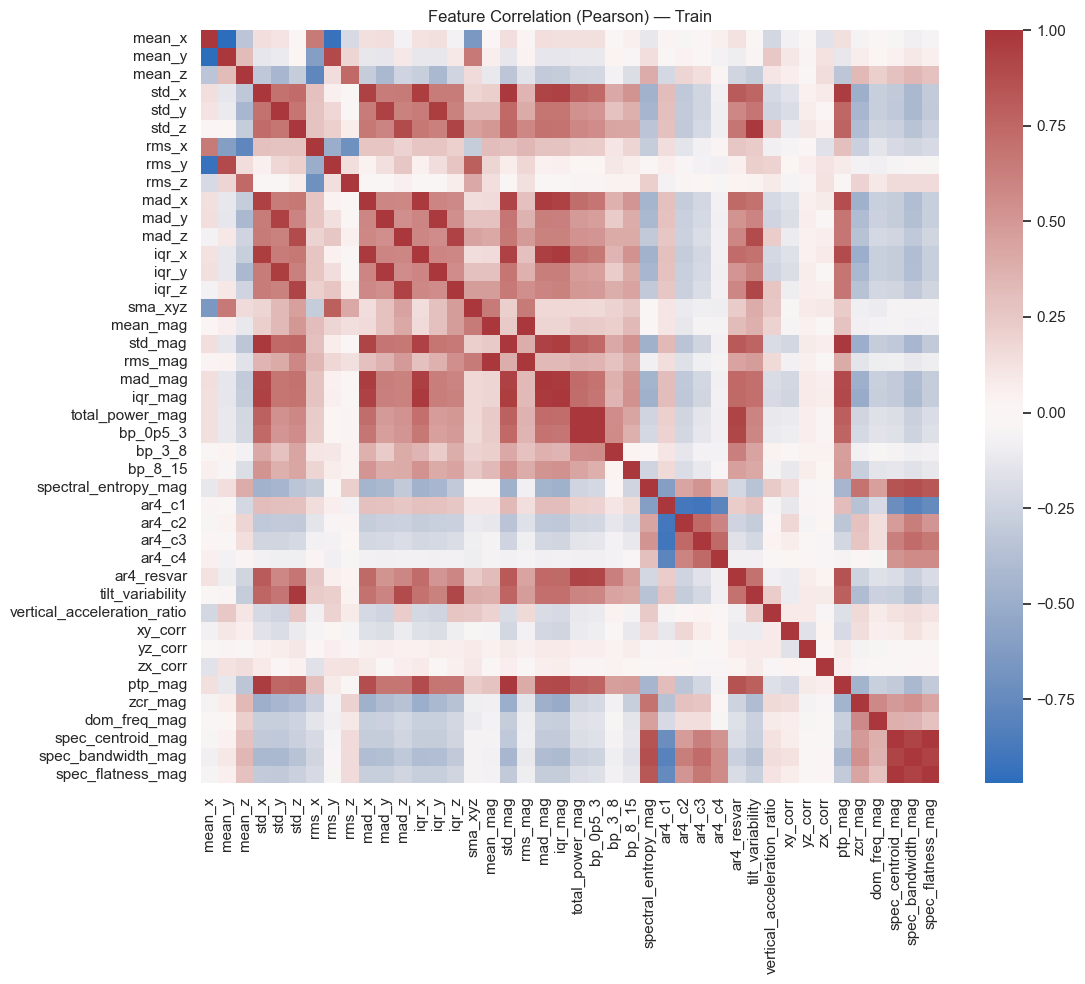

Top 10 features by η² (variance explained by class):


,feature,eta2
36,ptp_mag,0.642560
17,std_mag,0.639848
31,tilt_variability,0.633288
3,std_x,0.627321
5,std_z,0.597502
4,std_y,0.578027
20,iqr_mag,0.570379
12,iqr_x,0.565571
19,mad_mag,0.554033
9,mad_x,0.544140


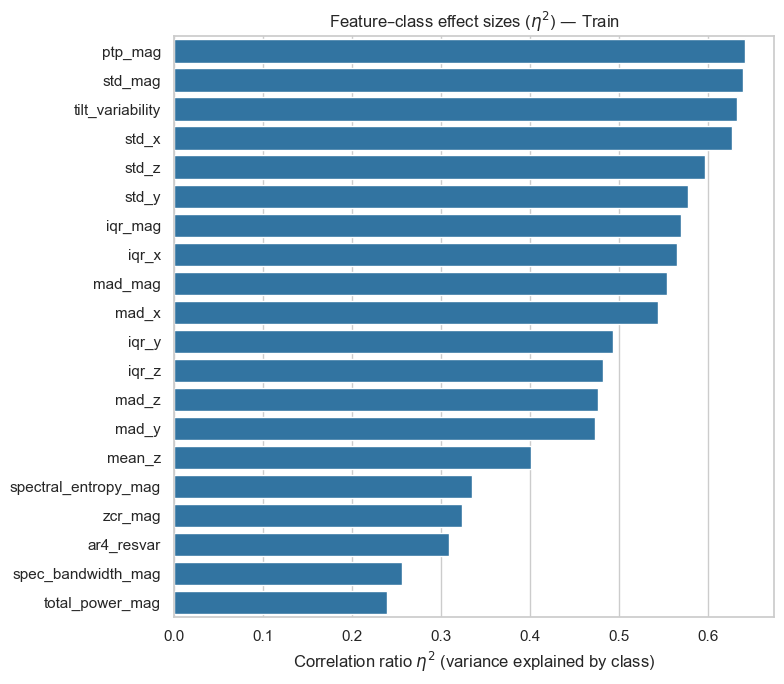

In [315]:
# ================== 2) FEATURE EXTRACTION ON EACH SPLIT ==================
# all features (36 total)
selected_features = [
    "mean_axis", "std_axis", "rms_axis", "mad_axis", "iqr_axis",
    "sma_xyz",
    "mean_mag", "std_mag", "rms_mag", "mad_mag", "iqr_mag",
    "total_power_mag",
    "bandpowers_mag",
    "spectral_entropy_mag",
    "ar_mag_coeffs",
    "tilt_variability", "vertical_acceleration_ratio",
    "xy_corr", "yz_corr", "zx_corr",
    "ptp_mag",
    "zcr_mag",
    "dom_freq_mag", "spec_centroid_mag", "spec_bandwidth_mag", "spec_flatness_mag"
]

# attach features in-place
attach_features_to_windows(windows_tr,  fs=FS, feature_names=selected_features, ar_order=4)
attach_features_to_windows(windows_val, fs=FS, feature_names=selected_features, ar_order=4)
attach_features_to_windows(windows_te,  fs=FS, feature_names=selected_features, ar_order=4)

# stack into matrices
Xf_tr, yf_tr, feat_names = stack_features(windows_tr)
Xf_val, yf_val, _        = stack_features(windows_val)
Xf_te,  yf_te,  _        = stack_features(windows_te)

y_int_tr  = to_intensity_labels(yf_tr)
y_int_val = to_intensity_labels(yf_val)
y_int_te  = to_intensity_labels(yf_te)

print("TRAIN feature matrix:", Xf_tr.shape)
print("VAL   feature matrix:", Xf_val.shape)
print("TEST  feature matrix:", Xf_te.shape)

# ================== 3) CLASSWISE SUMMARY STATS ==================

mean_tbl_tr, med_tbl_tr = classwise_stats(Xf_tr, yf_tr, feat_names)
mean_tbl_val, med_tbl_val = classwise_stats(Xf_val, yf_val, feat_names)
mean_tbl_te,  med_tbl_te  = classwise_stats(Xf_te,  yf_te,  feat_names)

print("TRAIN class-wise means:\n", mean_tbl_tr.head())
print("TRAIN class-wise medians:\n", med_tbl_tr.head())

# ================== 4) FEATURE DISTRIBUTIONS BY CLASS (MULTI-CLASS) ==================

plot_features_grid_by_class(
    Xf_tr, yf_tr, feat_names,
    features=[
        "mean_x", "mean_y", "mean_z",
        "std_x", "std_y", "std_z",
        "rms_x", "rms_y", "rms_z",
        "sma_xyz",
        "mean_mag", "std_mag", "rms_mag",
        "total_power_mag",
        "bp_0p5_3", "bp_3_8", "bp_8_15",
        "spectral_entropy_mag",
        "tilt_variability",
        "vertical_acceleration_ratio",
        "xy_corr", "yz_corr", "zx_corr",
        "ptp_mag", "zcr_mag",
        "dom_freq_mag", "spec_centroid_mag", "spec_bandwidth_mag", "spec_flatness_mag"
    ],
    kind="violin",
    ncols=3,
    suptitle="Selected Features by Class — Train",
)

# ================== 5) FEATURE–FEATURE & FEATURE–CLASS CORRELATIONS ==================

# (a) Feature–feature Pearson correlation heatmap (multi-class agnostic)
feature_corr_heatmap(
    Xf_tr,
    feat_names,
    title="Feature Correlation (Pearson) — Train",
)

# (b) Correlation ratio η²(feature, class) – multi-class analogue to r_pb / Fisher
eta_tbl = correlation_ratio_table(
    Xf_tr,
    yf_tr,
    feat_names,
)

print("Top 10 features by η² (variance explained by class):")
display(eta_tbl.head(10))

plot_feature_class_effects(
    eta_tbl,
    top_k=20,
    title=r"Feature–class effect sizes ($\eta^2$) — Train",
)




## 3.3. Feature Selection For Intensity-Based Preclassifier
First we will route activities using a preclassifier, to separate high intensity (walk/turn) from low intensity (stand/sit).
The feature selection pipeline will have three steps:
1. Filter using discriminability (which features are the most discriminative?): using a combined score of Fisher, Point-biserial correlation with output class and mutual information. Keep only the top 9 features (reducing search space for wrappers to avoid overfitting).
   1. Fisher score: between class vs within class separation for ability to create distinct classes
   2. Point-biserial for linear discriminability for binary labels
   3. Mutual information for non linear dependency with label
2. Remove redundancy (any pairwise correlation with p>0.8) to ensure independence.
3. Small wrapper (SFS or 1-3 step RFE) on training data ONLY to select best combinations of the remaining features -> end up with 5.

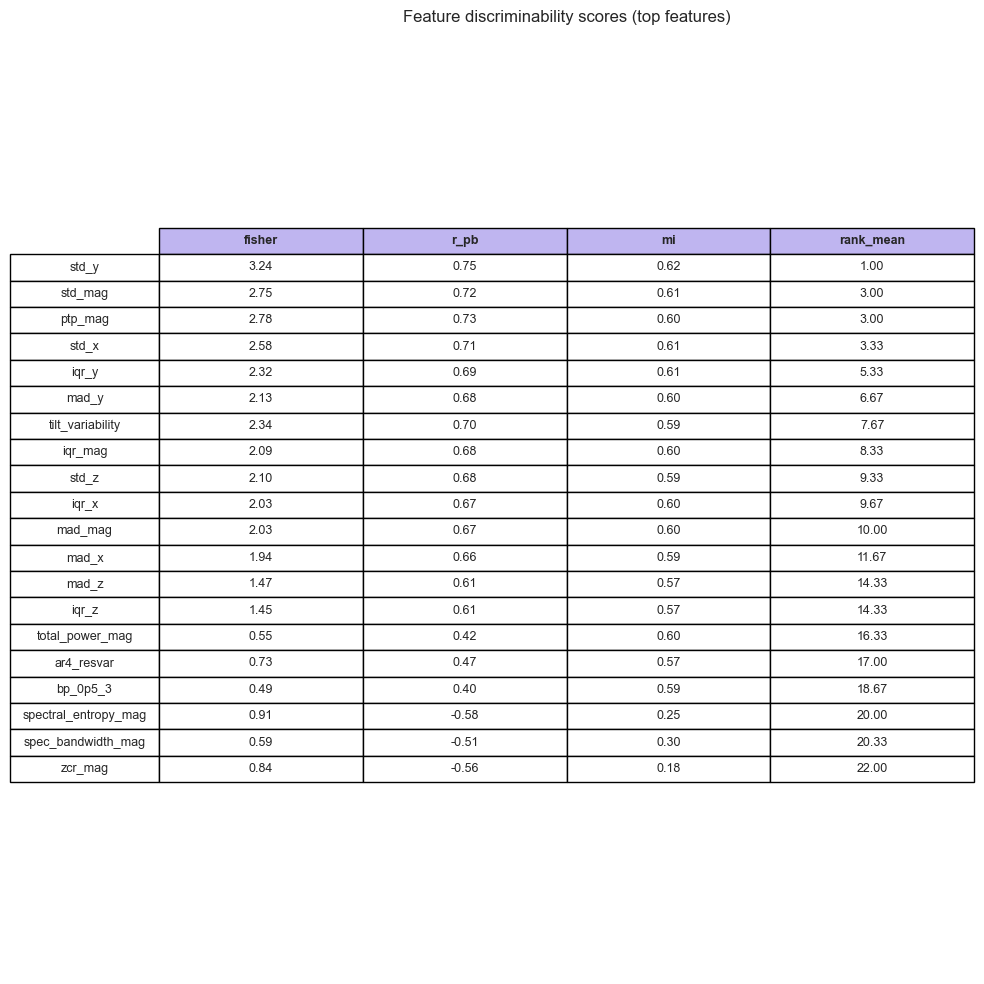

Selected features: ['std_y', 'std_mag', 'tilt_variability', 'total_power_mag']


C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:581: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:581: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:581: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:581: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsd

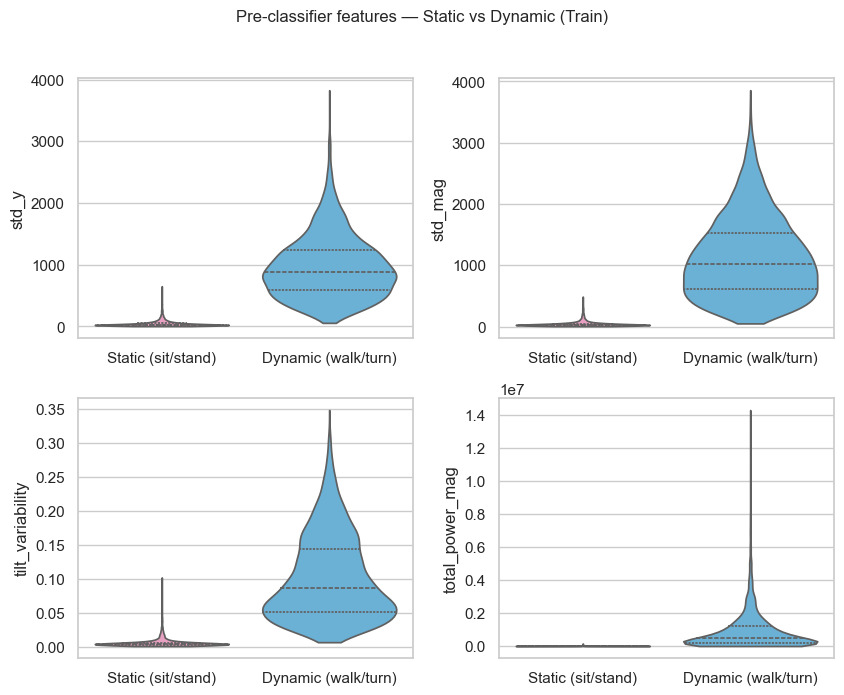

In [316]:
# (1) FILTER USING DISCRIMINABILITY
def plot_discriminability_table(
    disc_df: pd.DataFrame,
    top_k: int = 20,
    figsize=None,
    title: str = "Feature discriminability scores (top features)",
):
    """
    Render the discriminability table as a figure with numeric values.
    Shows, for top_k features by rank_mean:
      - fisher
      - r_pb
      - mi
      - rank_mean
    """
    top_k = min(top_k, len(disc_df))
    # Take top_k best features
    df_plot = disc_df.head(top_k).copy()

    # We usually want to show the "best" at the top in the table
    cols_to_show = ["fisher", "r_pb", "mi", "rank_mean"]
    df_show = df_plot[cols_to_show].copy()

    df_show_fmt = df_show.copy()
    for c in cols_to_show:
        df_show_fmt[c] = df_show[c].map(lambda v: f"{v:.2f}")

    # Feature names as row labels
    row_labels = df_show_fmt.index.tolist()
    cell_text = df_show_fmt.values

    if figsize is None:
        figsize = (10, 0.4 * top_k + 2)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=cols_to_show,
        loc="center",
        cellLoc="center",
        rowLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.3) 

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
        # You can also tweak header background if you want:
        if row == 0:
             cell.set_facecolor("#bfb5f0")

    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

    
def discriminability_table(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    random_state: int = SEED
) -> pd.DataFrame:
    """
    Build a table of discriminability metrics:
      - Fisher score
      - point-biserial correlation
      - mutual information
    and a combined rank (lower is better).
    """
    # *** HARD CAST TO FLOAT ***
    Xf = np.asarray(Xf, dtype=float)
    y = np.asarray(y)

    # (1) Fisher scores (use helper function from before)
    fs = fisher_scores(Xf, y, colnames)   # index = feature name

    # (2) Point-biserial (use helper function from before)
    pb = point_biserial_table(Xf, y, colnames).set_index("feature")

    # (3) Mutual information
    mi = mutual_info_classif(Xf, y, random_state=random_state)
    mi_ser = pd.Series(mi, index=colnames, name="mi")

    # Assemble into one table, indexed by feature name
    df = pd.DataFrame(index=colnames)
    df["fisher"] = fs.reindex(colnames)
    df["r_pb"]   = pb["r_pb"].reindex(colnames)
    df["mi"]     = mi_ser

    # Ranks (higher score = more discriminative → lower rank value)
    df["rank_fisher"]   = df["fisher"].rank(ascending=False)
    df["rank_abs_r_pb"] = df["r_pb"].abs().rank(ascending=False)
    df["rank_mi"]       = df["mi"].rank(ascending=False)

    df["rank_mean"] = df[["rank_fisher", "rank_abs_r_pb", "rank_mi"]].mean(axis=1)

    # Sort by combined rank (best at top)
    df = df.sort_values("rank_mean")
    plot_discriminability_table(df)

    return df


# (2) CORRELATION FILTER (REMOVE REDUNDANCIES)
def corr_prune_from_rank(
    Xf: np.ndarray,
    colnames: List[str],
    ranked_features: List[str],
    corr_thr: float = 0.8,
    max_candidates: Optional[int] = None,
) -> Tuple[List[str], List[int]]:
    """
    Correlation pruning:
    - ranked_features: feature names in priority order (best → worst)
    - keep a feature only if |rho| with all already-kept features < corr_thr.
    - stop after max_candidates if given.
    """
    name_to_idx = {name: i for i, name in enumerate(colnames)}

    selected_names: List[str] = []
    selected_idx: List[int] = []

    for name in ranked_features:
        idx = name_to_idx[name]

        if not selected_idx:
            selected_names.append(name)
            selected_idx.append(idx)
        else:
            corrs = [np.corrcoef(Xf[:, idx], Xf[:, j])[0, 1] for j in selected_idx]
            if np.max(np.abs(corrs)) < corr_thr:
                selected_names.append(name)
                selected_idx.append(idx)

        if max_candidates is not None and len(selected_names) >= max_candidates:
            break

    return selected_names, selected_idx


# (3) SMALL WRAPPER FUNCTION ON TRAINING DATA ONLY TO SELECT 5 BEST FEATURES
def sfs_wrapper_svm(
    Xf: np.ndarray,
    y: np.ndarray,
    colnames: List[str],
    candidate_names: List[str],
    max_features: int = 20,
    C: float = 4.0,
    gamma: str = "scale",
    cv_folds: int = 3,
    random_state: int = SEED, 
) -> Tuple[List[str], List[int]]:
    """
    Very small forward selection (SFS) on top of pruned candidates.
    Returns selected feature names and indices (w.r.t. colnames).
    """
    y = np.asarray(y)
    name_to_idx = {name: i for i, name in enumerate(colnames)} # map from feature name -> column index in Xf
    candidate_idx = [name_to_idx[n] for n in candidate_names] # convert feature candidate_names into their column indices 

    selected: List[int] = [] # will store the indices of ftr cols we pick as we go
    remaining = candidate_idx.copy() # ftr indices we haven't checked yet

    # stratifiedKFold splits the data into 'cv_folds' parts with roughly the same class proportions as the full dataset
    cv = StratifiedKFold(n_splits=max(2, cv_folds), shuffle=True, random_state=random_state) # at least 2 folds

    # forward selection loop until we have 5 features
    while remaining and len(selected) < max_features:
        best_j = None
        best_score = -np.inf # init

        for j in remaining:
            cols = selected + [j]
            X_sub = Xf[:, cols]
            clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=random_state) # kernel svm
            # train 'clf' on (cv_folds -1), test on the remaining fold; repeat for each fold; return an array of accuracies (one per fold)
            scores = cross_val_score(clf, X_sub, y, cv=cv)
            score = scores.mean() # take the mean accuracy across all folds

            # keep track of best candidate this round
            if score > best_score:
                best_score = score
                best_j = j

        selected.append(best_j)
        remaining.remove(best_j)

    sel_names = [colnames[i] for i in selected]
    return sel_names, selected


# COMBINE 3 STEPS FOR FEATURE SELECTION PIPELINE
def select_features_pipeline(
    Xf_tr: np.ndarray,
    y_tr: np.ndarray,
    feat_names: List[str],
    fisher_top_k: int = 9,
    corr_thr: float = 0.8,
    max_features: int = 5,
    use_wrapper: bool = True,
) -> Tuple[List[str], List[int], pd.DataFrame]:
    """
    3-step feature selection on TRAIN features only:

    1) Filter: discriminability (Fisher + |r_pb| + MI)
    2) Corr prune: remove redundancy with |rho| > corr_thr.
    3) (optional) small wrapper (SFS with SVM) on pruned set

    Returns:
      selected_names, selected_indices, disc_table (full discriminability DataFrame)
    """
    # 1) Discriminability filter
    disc_df = discriminability_table(Xf_tr, y_tr, feat_names)
    ranked_feats = disc_df.index.tolist()
    top_feats = ranked_feats[:min(fisher_top_k, len(ranked_feats))]

    # 2) Correlation pruning
    pruned_names, pruned_idx = corr_prune_from_rank(
        Xf_tr, feat_names, top_feats,
        corr_thr=corr_thr,
        max_candidates=None
    )

    if not use_wrapper:
        # Just take the first max_features after pruning
        final_names = pruned_names[:max_features]
        final_idx = [feat_names.index(n) for n in final_names]
        return final_names, final_idx, disc_df

    # 3) Small wrapper (SFS) over the pruned set
    final_names, final_idx = sfs_wrapper_svm(
        Xf_tr, y_tr,
        feat_names,
        candidate_names=pruned_names,
        max_features=max_features,
    )

    return final_names, final_idx, disc_df

# FEATURE SELECTION ON TRAIN ONLY
sel_names, sel_idx, disc_df = select_features_pipeline(
    Xf_tr, y_int_tr, feat_names,
    fisher_top_k=15,
    corr_thr=0.85,
    max_features=5,
    use_wrapper=True
)

print("Selected features:", sel_names)

# Reduce train/val/test to selected columns = TRAINING SET
Xf_tr_sel = Xf_tr[:, sel_idx]
Xf_val_sel = Xf_val[:, sel_idx]
Xf_te_sel  = Xf_te[:,  sel_idx]

# Grid of all selected intensity features
plot_intensity_features_grid(
    Xf_tr_sel,
    y_4class=yf_tr,
    colnames=sel_names,
    features=sel_names,
    kind="violin",
    ncols=2,
    suptitle="Pre-classifier features — Static vs Dynamic (Train)",
)

## 3.4. Feature Selection for Static and Dynamic SVMs
- Now we need to choose the best features that discriminate sit vs stand and walk vs turn, as opposed to the previous dynamic vs static.
- Essentially we will make a wrapper to filter Xf_tr/yf_tr down to the two classes we care about in either case -> convert to binary labels and use existing select_features_pipeline unchanged.

In [317]:
# =============== FEATURE SELECTION FOR PAIRWISE SVMs ==================

def _subset_pair_binary(
    Xf: np.ndarray,
    y_4class: np.ndarray,
    feat_names: list[str],
    pos_ids: set[int],
    neg_ids: set[int],
    pos_label_name: str,
    neg_label_name: str,
):
    """
    Restrict (Xf, y_4class) to a binary pair of classes.

    pos_ids: set of 4-class IDs to map to 1 (e.g. {walk_id})
    neg_ids: set of 4-class IDs to map to 0 (e.g. {turn_id})
    """
    y_4class = np.asarray(y_4class)

    # keep only samples from the two classes of interest
    mask = np.isin(y_4class, list(pos_ids | neg_ids))
    X_pair = Xf[mask].astype(float)
    y_pair_4 = y_4class[mask]

    # map to 0/1
    y_bin = np.where(np.isin(y_pair_4, list(pos_ids)), 1, 0)

    print(f"[PAIR] {neg_label_name}=0 vs {pos_label_name}=1")
    print("  counts:", {int(k): int(v) for k, v in zip(*np.unique(y_bin, return_counts=True))})

    return X_pair, y_bin, mask


def select_features_for_pairwise_svm(
    Xf_tr: np.ndarray,
    yf_tr_4class: np.ndarray,
    feat_names: list[str],
    pos_ids: set[int],
    neg_ids: set[int],
    pos_label_name: str,
    neg_label_name: str,
    fisher_top_k: int = 10,
    corr_thr: float = 0.85,
    max_features: int = 5,
    use_wrapper: bool = True,
):
    """
    Convenience wrapper:

      1) Restrict TRAIN windows to the two target activities.
      2) Map them to binary labels (0/1).
      3) Run existing select_features_pipeline on that binary subset.

    Returns
    -------
    sel_names : list[str]              # selected feature names
    sel_idx   : list[int]              # indices into feat_names (global columns)
    disc_df   : pd.DataFrame           # discriminability table (for the pair)
    mask_tr   : np.ndarray[bool]       # which training windows were kept
    y_bin_tr  : np.ndarray[int]        # 0/1 labels corresponding to Xf_tr[mask_tr]
    """
    # 1) restrict & binarize
    X_pair_tr, y_pair_tr, mask_tr = _subset_pair_binary(
        Xf_tr,
        yf_tr_4class,
        feat_names,
        pos_ids=pos_ids,
        neg_ids=neg_ids,
        pos_label_name=pos_label_name,
        neg_label_name=neg_label_name,
    )

    # 2) run the select_features_pipeline on the binarized training set
    sel_names, sel_idx, disc_df = select_features_pipeline(
        X_pair_tr,
        y_pair_tr,
        feat_names,
        fisher_top_k=fisher_top_k,
        corr_thr=corr_thr,
        max_features=max_features,
        use_wrapper=use_wrapper,
    )

    print(f"[PAIR FS] Selected features for {neg_label_name} vs {pos_label_name}:")
    for name in sel_names:
        print("   -", name)

    return sel_names, sel_idx, disc_df, mask_tr, y_pair_tr


- Now we can select the features for static and dynamic SVM in the same way we did for the preclassifier.

[PAIR] sit=0 vs stand=1
  counts: {0: 1299, 1: 1268}


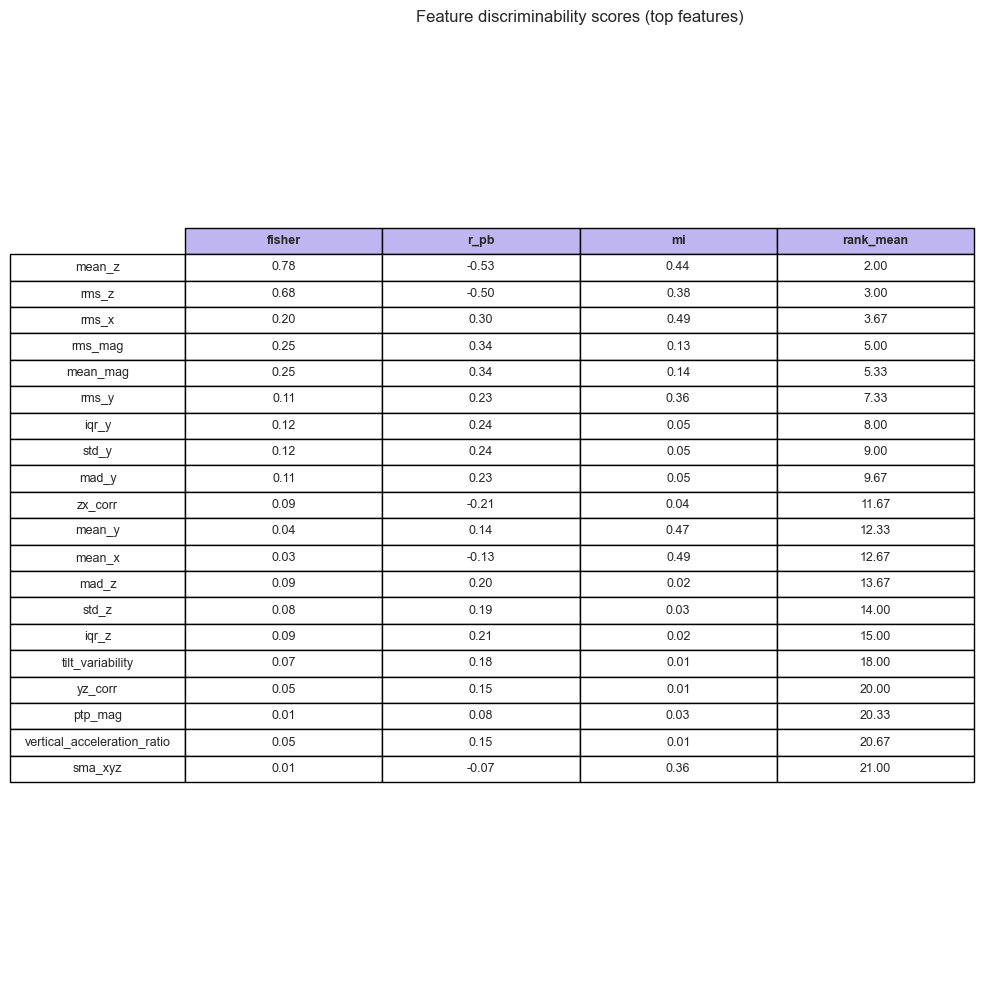

[PAIR FS] Selected features for sit vs stand:
   - mean_z
   - rms_y
   - ar4_resvar
   - ptp_mag
   - mad_z
   - yz_corr
   - zx_corr
   - vertical_acceleration_ratio
   - zcr_mag
   - iqr_y
   - rms_mag
[PAIR] turn=0 vs walk=1
  counts: {0: 1488, 1: 2368}


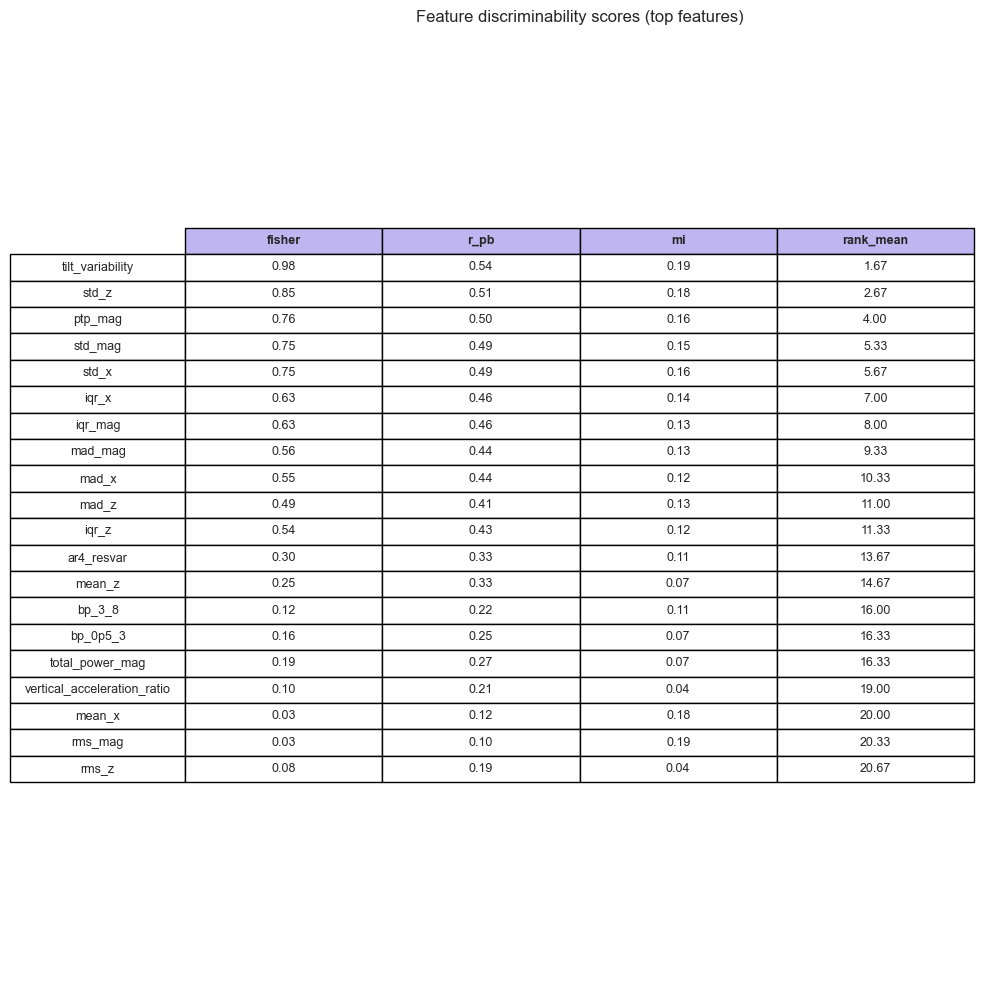

[PAIR FS] Selected features for turn vs walk:
   - tilt_variability
   - zcr_mag
   - vertical_acceleration_ratio
   - ptp_mag
   - mean_z
   - rms_z
   - mean_x
   - iqr_x
   - mad_z
   - rms_mag
   - std_y
   - bp_8_15
   - bp_3_8
   - ar4_resvar


In [ ]:
# ---------- Static SVM: sit vs stand ----------

sel_static_names, sel_static_idx, disc_static_df, mask_tr_static, y_tr_static_bin = (
    select_features_for_pairwise_svm(
        Xf_tr,
        yf_tr,
        feat_names,
        pos_ids=STATIC_PAIR_POS,
        neg_ids=STATIC_PAIR_NEG,
        pos_label_name="stand",
        neg_label_name="sit",
        fisher_top_k=23,
        corr_thr=0.85,
        max_features=20,
        use_wrapper=True,
    )
)

# Build train/val/test matrices for the static SVM using these features
mask_val_static = np.isin(yf_val, list(STATIC_PAIR_POS | STATIC_PAIR_NEG))
mask_te_static  = np.isin(yf_te,  list(STATIC_PAIR_POS | STATIC_PAIR_NEG))

X_tr_static = Xf_tr[mask_tr_static][:, sel_static_idx]
X_val_static = Xf_val[mask_val_static][:, sel_static_idx]
X_te_static  = Xf_te[mask_te_static][:,  sel_static_idx]

# Binary labels for val/test (0=sit, 1=stand)
y_val_static_bin = np.where(np.isin(yf_val[mask_val_static], list(STATIC_PAIR_POS)), 1, 0)
y_te_static_bin  = np.where(np.isin(yf_te[mask_te_static],  list(STATIC_PAIR_POS)), 1, 0)

# ---------- Dynamic SVM: walk vs turn ----------

sel_dyn_names, sel_dyn_idx, disc_dyn_df, mask_tr_dyn, y_tr_dyn_bin = (
    select_features_for_pairwise_svm(
        Xf_tr,
        yf_tr,
        feat_names,
        pos_ids=DYNAMIC_PAIR_POS,
        neg_ids=DYNAMIC_PAIR_NEG,
        pos_label_name="walk",
        neg_label_name="turn",
        fisher_top_k=23,
        corr_thr=0.85,
        max_features=20,
        use_wrapper=True,
    )
)

mask_val_dyn = np.isin(yf_val, list(DYNAMIC_PAIR_POS | DYNAMIC_PAIR_NEG))
mask_te_dyn  = np.isin(yf_te,  list(DYNAMIC_PAIR_POS | DYNAMIC_PAIR_NEG))

X_tr_dyn = Xf_tr[mask_tr_dyn][:, sel_dyn_idx]
X_val_dyn = Xf_val[mask_val_dyn][:, sel_dyn_idx]
X_te_dyn  = Xf_te[mask_te_dyn][:,  sel_dyn_idx]

# Binary labels for val/test (0=turn, 1=walk)
y_val_dyn_bin = np.where(np.isin(yf_val[mask_val_dyn], list(DYNAMIC_PAIR_POS)), 1, 0)
y_te_dyn_bin  = np.where(np.isin(yf_te[mask_te_dyn],  list(DYNAMIC_PAIR_POS)), 1, 0)



## 4. Formulate Decision Function: Build Threshold Function for Preclassifier + Train the two SVMs
- We need a function that takes in the selected features for the preclassifier and returns static or dynamic. We will use logistic regression for this.
- We need to tune hyperparameters (c, gamma) using a simple manual grid search
- Complete SVM training on training set
- Use val set for hyperparam tuning

## 4.1. Preclassifier

In [319]:
# Train intensity pre-classifier on TRAIN (selected features only)
def train_intensity_preclassifier(
    X_tr_sel: np.ndarray,
    y_int_tr: np.ndarray,
    random_state: int = SEED,
) -> Pipeline:
    """
    Small linear pre-classifier:
      - StandardScaler
      - LogisticRegression (binary: 0=static, 1=dynamic)
    """
    y_int_tr = np.asarray(y_int_tr)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state,
        )),
    ])

    pipe.fit(X_tr_sel, y_int_tr)
    return pipe

# train it
intensity_clf = train_intensity_preclassifier(Xf_tr_sel, y_int_tr, random_state=SEED)

## 4.2. SVMs

In [320]:
def tune_svm_hyperparams(
    X: np.ndarray,
    y: np.ndarray,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds: int = 5,
    random_state: int = SEED,
) -> Tuple[float, str, pd.DataFrame]:
    """
    Hyperparameter tuning on TRAIN with 5-fold cross-validation to get initial best candidates
    *Scaling is included inside the sklearn pipeline.

    Returns
    -------
    best_C : float
    best_gamma : str or float
    results_df : pd.DataFrame with columns [C, gamma, mean_acc, std_acc]
    """
    y = np.asarray(y)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    rows = []
    best_score = -np.inf
    best_C = None
    best_gamma = None

    # Grid search
    for C in C_grid:
        for gamma in gamma_grid:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(
                    kernel="rbf",
                    C=C,
                    gamma=gamma,
                    class_weight="balanced",
                    random_state=random_state,
                )),
            ])

            scores = cross_val_score(pipe, X, y, cv=cv)
            mean_acc = scores.mean()
            std_acc = scores.std()

            rows.append({
                "C": C,
                "gamma": gamma,
                "mean_acc": mean_acc,
                "std_acc": std_acc,
            })

            # keep track of current best in search
            if mean_acc > best_score:
                best_score = mean_acc
                best_C = C
                best_gamma = gamma

    results_df = pd.DataFrame(rows).sort_values("mean_acc", ascending=False).reset_index(drop=True)
    return best_C, best_gamma, results_df

# Final training SVM helper with the best hyperparams
def train_svm_rbf(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    C: float,
    gamma,
    random_state: int = SEED,
) -> Pipeline:
    """
    Train a final RBF SVM (with scaling) on the given training data
    using the supplied hyperparameters.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight="balanced",
            probability=True, 
            random_state=random_state,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe


,C,gamma,mean_acc,std_acc
0,8.0,scale,0.933770,0.011848
1,8.0,0.1,0.932211,0.013609
2,4.0,scale,0.927926,0.013973
3,4.0,0.1,0.927926,0.014242
4,2.0,scale,0.921691,0.014382


[STATIC] (C=8.0, gamma=scale) -> Val Acc = 0.9417
[STATIC] (C=8.0, gamma=0.1) -> Val Acc = 0.9430
[STATIC] (C=4.0, gamma=scale) -> Val Acc = 0.9404
[STATIC] (C=4.0, gamma=0.1) -> Val Acc = 0.9417
[STATIC] (C=2.0, gamma=scale) -> Val Acc = 0.9354
[STATIC] (C=2.0, gamma=0.1) -> Val Acc = 0.9341

[STATIC] Final hyperparameters based on VAL:
  C_final     = 8.0
  gamma_final = 0.1
  Val accuracy= 0.9430
[STATIC] Test accuracy = 0.9359


C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parame

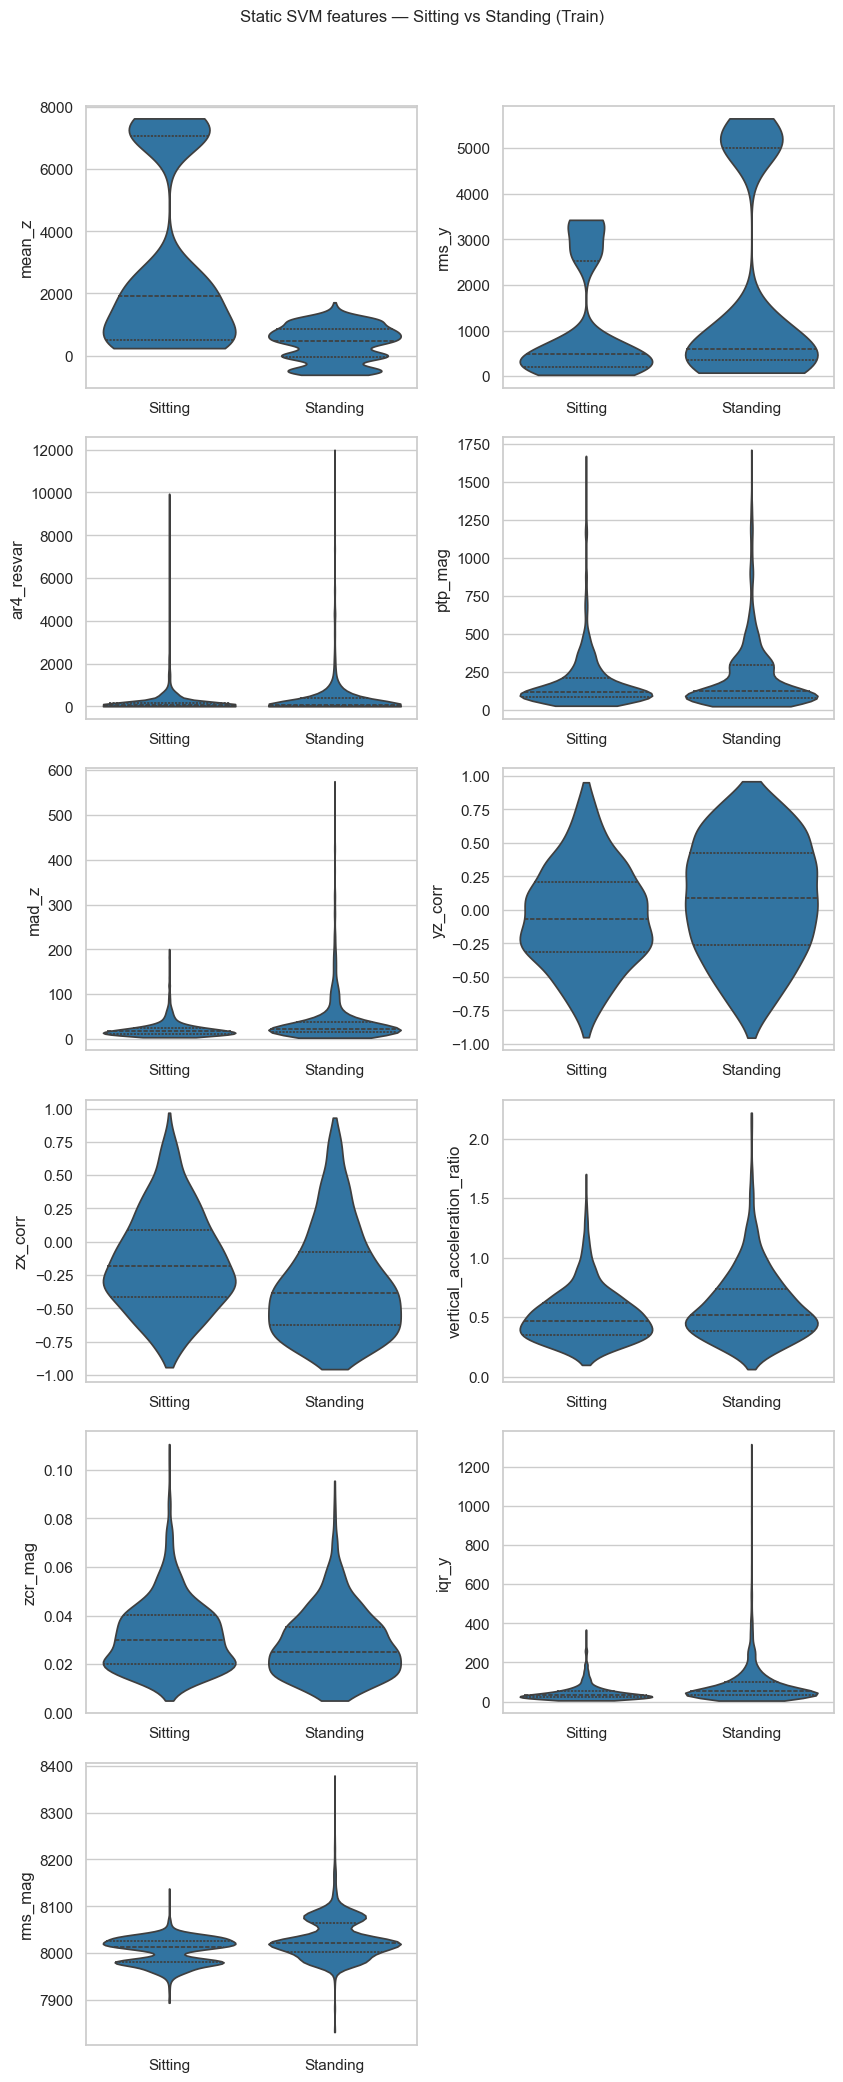

,C,gamma,mean_acc,std_acc
0,8.0,scale,0.915456,0.005829
1,8.0,0.1,0.915196,0.007554
2,4.0,0.1,0.914678,0.005531
3,4.0,scale,0.911824,0.007359
4,2.0,0.1,0.911046,0.004921


[DYN] (C=8.0, gamma=scale) -> Val Acc = 0.9090
[DYN] (C=8.0, gamma=0.1) -> Val Acc = 0.9115
[DYN] (C=4.0, gamma=0.1) -> Val Acc = 0.9115
[DYN] (C=4.0, gamma=scale) -> Val Acc = 0.9082
[DYN] (C=2.0, gamma=0.1) -> Val Acc = 0.9082
[DYN] (C=2.0, gamma=scale) -> Val Acc = 0.9040

[DYN] Final hyperparameters based on VAL:
  C_final     = 8.0
  gamma_final = 0.1
  Val accuracy= 0.9115
[DYN] Test accuracy = 0.9258


C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\fsdma\AppData\Local\Temp\ipykernel_37116\2460454771.py:653: FutureWarning: 

The `scale` parame

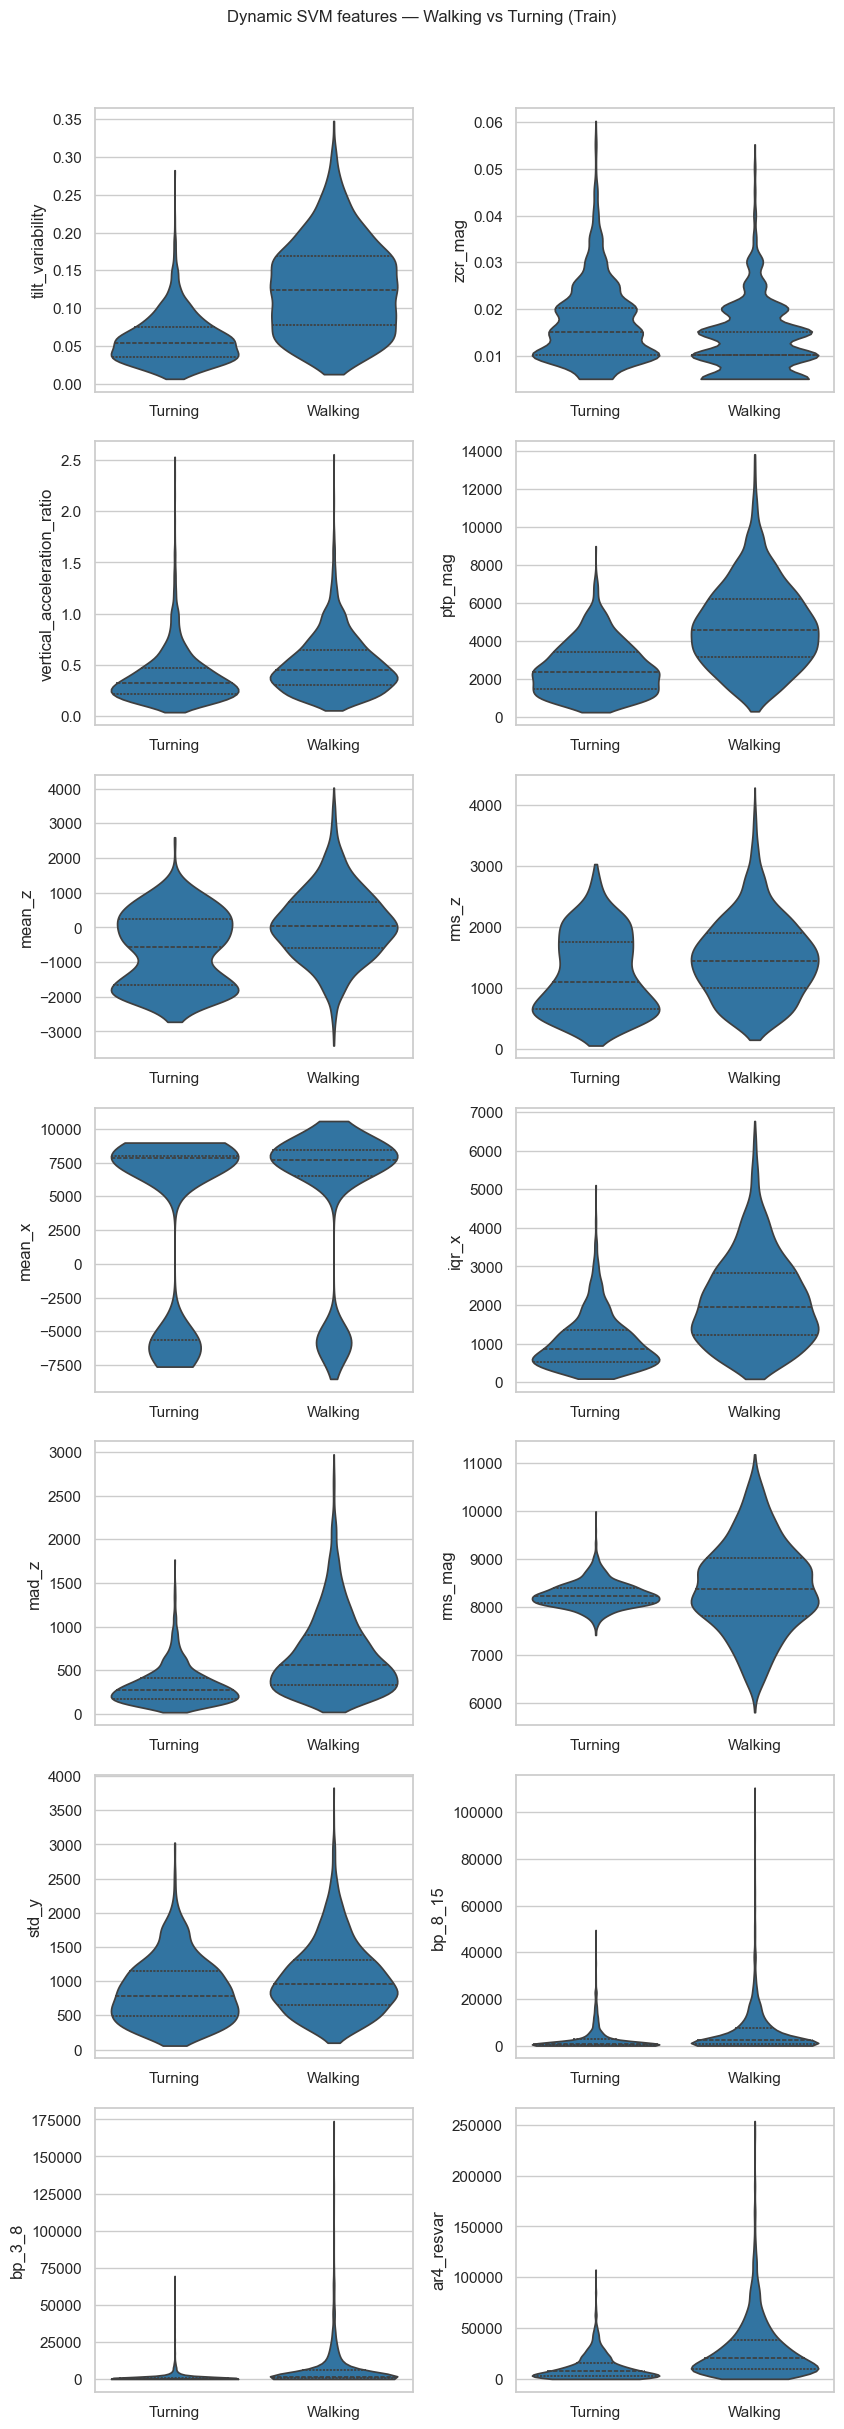

In [321]:
# ================= STATIC SVM: hyperparameter tuning =================

best_C_cv_static, best_gamma_cv_static, cv_table_static = tune_svm_hyperparams(
    X_tr_static, y_tr_static_bin,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds=5,
    random_state=SEED,
)

display(cv_table_static.head())

# shortlist the best K from CV
top_k = 6
candidates_static = cv_table_static.head(top_k)

best_val_acc_static = -np.inf
best_C_static = None
best_gamma_static = None

for _, row in candidates_static.iterrows():
    C = row["C"]
    gamma = row["gamma"]

    model = train_svm_rbf(X_tr_static, y_tr_static_bin, C=C, gamma=gamma, random_state=SEED)

    y_val_pred = model.predict(X_val_static)
    val_acc = accuracy_score(y_val_static_bin, y_val_pred)

    print(f"[STATIC] (C={C}, gamma={gamma}) -> Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc_static:
        best_val_acc_static = val_acc
        best_C_static = C
        best_gamma_static = gamma

print("\n[STATIC] Final hyperparameters based on VAL:")
print(f"  C_final     = {best_C_static}")
print(f"  gamma_final = {best_gamma_static}")
print(f"  Val accuracy= {best_val_acc_static:.4f}")

# final static SVM
static_svm = train_svm_rbf(X_tr_static, y_tr_static_bin,
                           C=best_C_static, gamma=best_gamma_static, random_state=SEED)

y_te_pred_static = static_svm.predict(X_te_static)
test_acc_static = accuracy_score(y_te_static_bin, y_te_pred_static)
print(f"[STATIC] Test accuracy = {test_acc_static:.4f}")

# Build the pairwise train matrix (only static windows, only selected features)
X_tr_static = Xf_tr[mask_tr_static][:, sel_static_idx]
y_tr_static_4class = yf_tr[mask_tr_static]

# Violin plots for STATIC SVM selected features
plot_pair_features_grid(
    X_pair=X_tr_static,
    y_pair_4class=y_tr_static_4class,
    colnames=sel_static_names,   # names for the selected columns
    features=sel_static_names,   # plot all selected features
    kind="violin",
    ncols=2,
    suptitle="Static SVM features — Sitting vs Standing (Train)",
)


# ================= DYNAMIC SVM: hyperparameter tuning =================

best_C_cv_dyn, best_gamma_cv_dyn, cv_table_dyn = tune_svm_hyperparams(
    X_tr_dyn, y_tr_dyn_bin,
    C_grid=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_grid=("scale", 0.01, 0.1, 1.0),
    cv_folds=5,
    random_state=SEED,
)

display(cv_table_dyn.head())

candidates_dyn = cv_table_dyn.head(top_k)

best_val_acc_dyn = -np.inf
best_C_dyn = None
best_gamma_dyn = None

for _, row in candidates_dyn.iterrows():
    C = row["C"]
    gamma = row["gamma"]

    model = train_svm_rbf(X_tr_dyn, y_tr_dyn_bin, C=C, gamma=gamma, random_state=SEED)

    y_val_pred = model.predict(X_val_dyn)
    val_acc = accuracy_score(y_val_dyn_bin, y_val_pred)

    print(f"[DYN] (C={C}, gamma={gamma}) -> Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc_dyn:
        best_val_acc_dyn = val_acc
        best_C_dyn = C
        best_gamma_dyn = gamma

print("\n[DYN] Final hyperparameters based on VAL:")
print(f"  C_final     = {best_C_dyn}")
print(f"  gamma_final = {best_gamma_dyn}")
print(f"  Val accuracy= {best_val_acc_dyn:.4f}")

# final dynamic SVM
dyn_svm = train_svm_rbf(X_tr_dyn, y_tr_dyn_bin,
                        C=best_C_dyn, gamma=best_gamma_dyn, random_state=SEED)

y_te_pred_dyn = dyn_svm.predict(X_te_dyn)
test_acc_dyn = accuracy_score(y_te_dyn_bin, y_te_pred_dyn)
print(f"[DYN] Test accuracy = {test_acc_dyn:.4f}")

# Build the pairwise train matrix (only dynamic windows, only selected features)
X_tr_dyn = Xf_tr[mask_tr_dyn][:, sel_dyn_idx]
y_tr_dyn_4class = yf_tr[mask_tr_dyn]  # still 0..3, but only walk/turn here

# Violin plots for DYNAMIC SVM selected features
plot_pair_features_grid(
    X_pair=X_tr_dyn,
    y_pair_4class=y_tr_dyn_4class,
    colnames=sel_dyn_names,
    features=sel_dyn_names,
    kind="violin",
    ncols=2,
    suptitle="Dynamic SVM features — Walking vs Turning (Train)",
)





## 4.3. Build (final) hiearchical preclassifier + 2 SVM model to separate the four classes.

In [333]:
# 1) callable wrapper for preclassifier prediction fn
def intensity_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    X_full: feature matrix with columns in the order of `feat_names`.
    Uses `sel_idx` and `intensity_clf` to output 0/1 (static/dynamic).
    """
    X_full = np.asarray(X_full, dtype=float)
    X_sel = X_full[:, sel_idx]
    return intensity_clf.predict(X_sel).astype(int)

# 2) wrappers for dynamic and static svm prediction fns
STATIC_SEL_IDX = sel_static_idx   
DYN_SEL_IDX    = sel_dyn_idx

def static_branch_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    Predict within the static branch: 0 = stand, 1 = sit
    """
    X_full = np.asarray(X_full, dtype=float)
    X_static = X_full[:, STATIC_SEL_IDX]
    return static_svm.predict(X_static)

def dynamic_branch_predict_fn(X_full: np.ndarray) -> np.ndarray:
    """
    Predict within the dynamic branch: 0 = walk, 1 = turn
    """
    X_full = np.asarray(X_full, dtype=float)
    X_dyn = X_full[:, DYN_SEL_IDX]
    return dyn_svm.predict(X_dyn)

# 3) put it all together for final decision fn
def hierarchical_predict_4class(X_full: np.ndarray) -> np.ndarray:
    """
    Full hierarchical HAR prediction:
      1) intensity_clf → 0=static, 1=dynamic
      2) static branch: static_svm → sit vs stand
      3) dynamic branch: dyn_svm   → turn vs walk

    Returns:
      y_pred_4: 1D array of 4-class IDs in {SIT_ID, STAND_ID, WALK_ID, TURN_ID}.
    """
    X_full = np.asarray(X_full, dtype=float)
    N = X_full.shape[0]

    # ----- 1) Intensity pre-classifier -----
    y_int = intensity_predict_fn(X_full)
    y_int = np.asarray(y_int, dtype=int).ravel()

    y_out = np.empty(N, dtype=int)

    # ----- 2) Static branch: sit vs stand -----
    mask_static = (y_int == 0)
    if np.any(mask_static):
        X_static = X_full[mask_static][:, sel_static_idx]   # slice static features
        y_static_bin = static_svm.predict(X_static)         # 0/1
        y_static_bin = np.asarray(y_static_bin, dtype=int).ravel()

        # 0 → Stand, 1 → Sit
        y_out[mask_static] = np.where(y_static_bin == 0, STAND_ID, SIT_ID)

    # ----- 3) Dynamic branch: turn vs walk -----
    mask_dyn = (y_int == 1)
    if np.any(mask_dyn):
        X_dyn = X_full[mask_dyn][:, sel_dyn_idx]            # slice dyn features
        y_dyn_bin = dyn_svm.predict(X_dyn)                  # 0/1
        y_dyn_bin = np.asarray(y_dyn_bin, dtype=int).ravel()

        # 0 → Walk, 1 → Turn
        y_out[mask_dyn] = np.where(y_dyn_bin == 0, WALK_ID, TURN_ID)

    return y_out


# 5. Measure Performance
- Now we can use the test set to measure performance.

In [334]:
def evaluate_model(
    X: np.ndarray,
    y: np.ndarray,
    split_name: str,
    predict_fn: Callable[[np.ndarray], np.ndarray],
    label_id_to_display: Dict[int, str],
    class_labels: Optional[Sequence[int]] = None,
    average: str = "macro",
    plot_cm: bool = True,
) -> Dict[str, float]:
    """
    Generic evaluation helper for *any* predictor function.

    - predict_fn(X) must return either:
        * 1D array of label IDs, or
        * 2D probs/logits (N, C), or
        * a tuple (y_pred, extra)
    - y: true label IDs (ints).
    """

    # --- Clean up y_true ---
    y_true = np.asarray(y)
    if y_true.ndim != 1:
        y_true = y_true.ravel()
    y_true = y_true.astype(int)

    # --- Call predictor and normalize output ---
    raw_pred = predict_fn(X)

    # handle tuple output (e.g. (y_pred, probs))
    if isinstance(raw_pred, tuple):
        y_pred = raw_pred[0]
    else:
        y_pred = raw_pred

    y_pred = np.asarray(y_pred)

    # if probabilities/logits or column vector
    if y_pred.ndim == 2:
        if y_pred.shape[1] == 1:
            y_pred = y_pred.ravel()
        else:
            # assume class scores → take argmax
            y_pred = np.argmax(y_pred, axis=1)

    if y_pred.ndim != 1:
        raise ValueError(f"predict_fn must return 1D labels or (N,C) scores; got shape {y_pred.shape}")

    y_pred = y_pred.astype(int)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Length mismatch: y_true={y_true.shape[0]}, y_pred={y_pred.shape[0]}")

    # --- Class labels for metrics / confusion matrix ---
    if class_labels is None:
        class_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))

    # --- Metrics ---
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        average=average,
        zero_division=0,
    )

    print(f"\n=== {split_name} metrics ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # --- Confusion matrix ---
    if plot_cm:
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        display_labels = [label_id_to_display[c] for c in class_labels]

        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        disp.plot(cmap="Blues")
        plt.title(f"{split_name} — Confusion Matrix")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

Test preclassifier:


=== Intensity - Train metrics ===
Accuracy : 0.9818
Precision: 0.9921
Recall   : 0.9774
F1-score : 0.9847


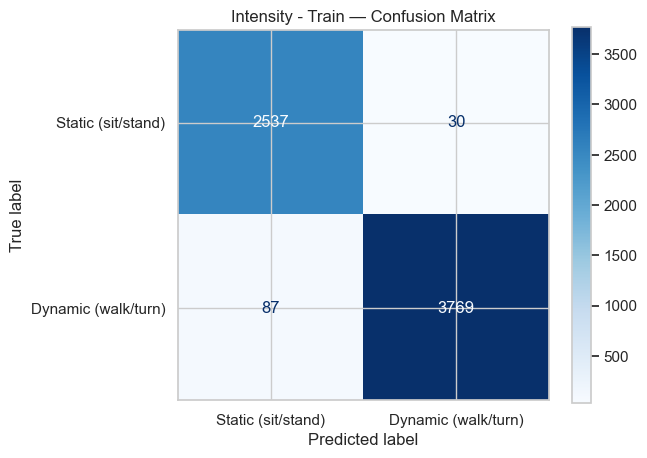


=== Intensity - Validation metrics ===
Accuracy : 0.9777
Precision: 0.9839
Recall   : 0.9789
F1-score : 0.9814


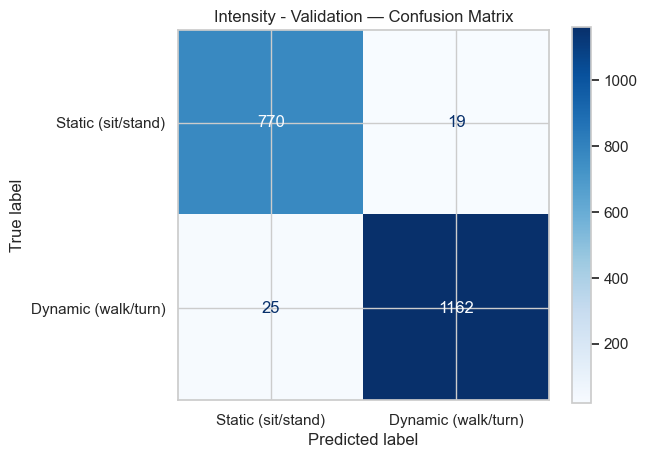


=== Intensity - Test metrics ===
Accuracy : 0.9825
Precision: 0.9843
Recall   : 0.9865
F1-score : 0.9854


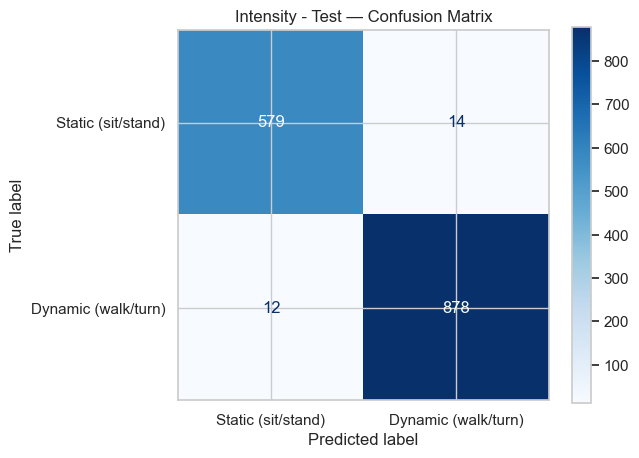

In [335]:
metrics_int_tr = evaluate_model(
    X=Xf_tr,
    y=y_int_tr,
    split_name="Intensity - Train",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],      # to force order Static, Dynamic
    average="binary",
)

metrics_int_val = evaluate_model(
    X=Xf_val,
    y=y_int_val,
    split_name="Intensity - Validation",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_int_te = evaluate_model(
    X=Xf_te,
    y=y_int_te,
    split_name="Intensity - Test",
    predict_fn=intensity_predict_fn,
    label_id_to_display=INTENSITY_LABELS,
    class_labels=[0, 1],
    average="binary",
)



Test SVMs


=== Static SVM – Train (Stand vs Sit) metrics ===
Accuracy : 0.9571
Precision: 0.9588
Recall   : 0.9543
F1-score : 0.9565


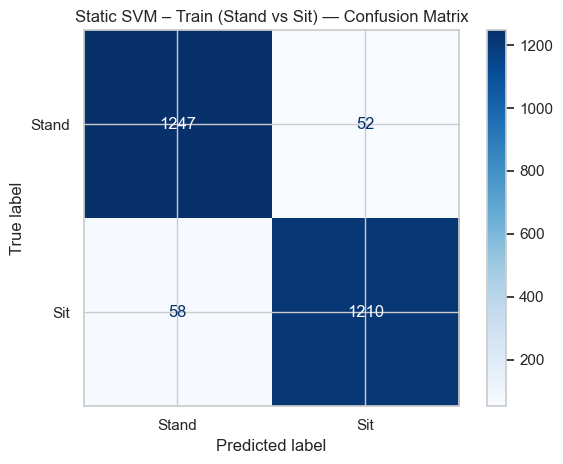


=== Static SVM – Validation (Stand vs Sit) metrics ===
Accuracy : 0.9430
Precision: 0.9259
Recall   : 0.9615
F1-score : 0.9434


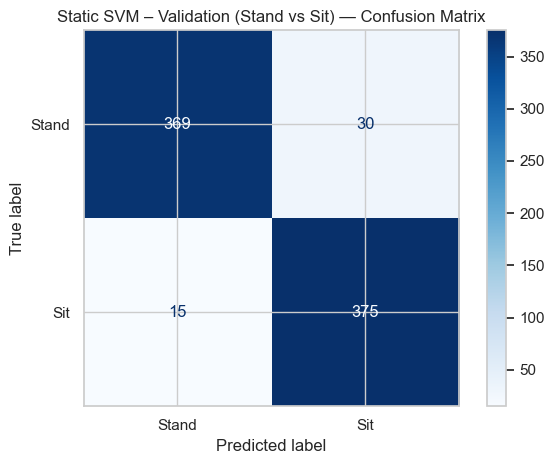


=== Static SVM – Test (Stand vs Sit) metrics ===
Accuracy : 0.9359
Precision: 0.9293
Recall   : 0.9420
F1-score : 0.9356


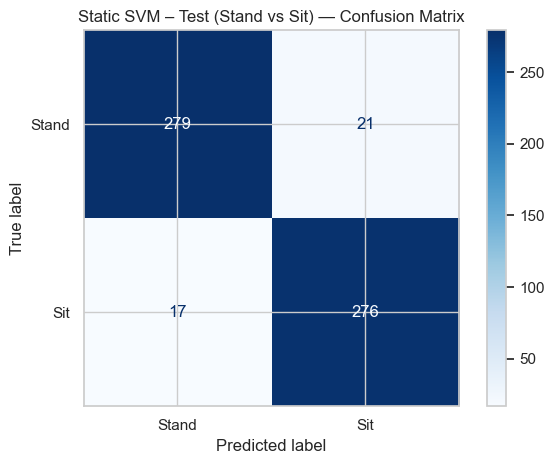


=== Dynamic SVM – Train (Walk vs Turn) metrics ===
Accuracy : 0.9466
Precision: 0.9927
Recall   : 0.9198
F1-score : 0.9548


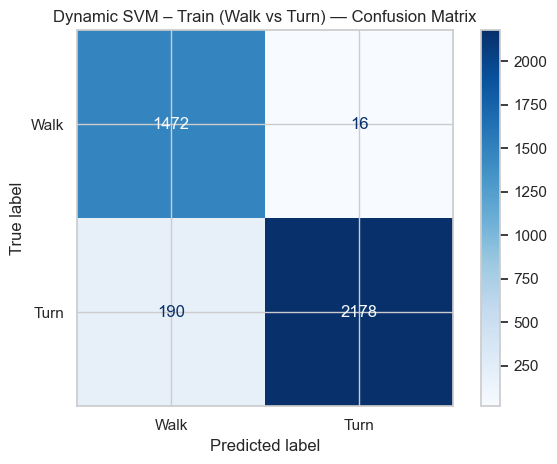


=== Dynamic SVM – Validation (Walk vs Turn) metrics ===
Accuracy : 0.9115
Precision: 0.9671
Recall   : 0.8861
F1-score : 0.9248


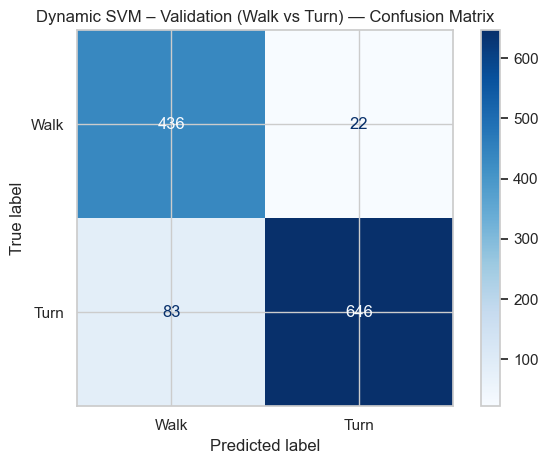


=== Dynamic SVM – Test (Walk vs Turn) metrics ===
Accuracy : 0.9258
Precision: 0.9688
Recall   : 0.9084
F1-score : 0.9376


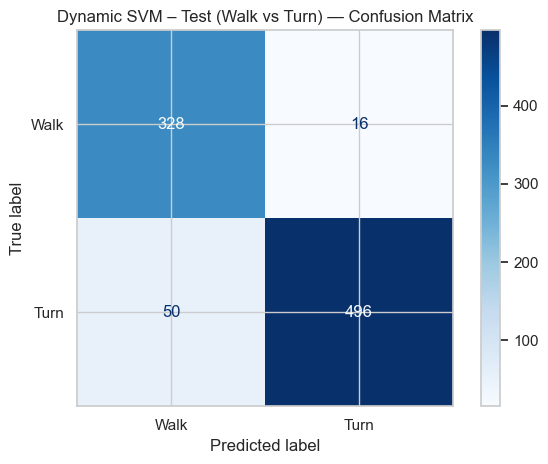

In [ ]:
# ---------- STATIC SVM: evaluation ----------

def static_predict_fn(X: np.ndarray) -> np.ndarray:
    """Wrapper so we can use evaluate_model with the static SVM pipeline."""
    return static_svm.predict(X)

metrics_static_tr = evaluate_model(
    X=X_tr_static,
    y=y_tr_static_bin,
    split_name="Static SVM – Train (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],     # 0=Stand, 1=Sit
    average="binary",
)

metrics_static_val = evaluate_model(
    X=X_val_static,
    y=y_val_static_bin,
    split_name="Static SVM – Validation (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_static_te = evaluate_model(
    X=X_te_static,
    y=y_te_static_bin,
    split_name="Static SVM – Test (Stand vs Sit)",
    predict_fn=static_predict_fn,
    label_id_to_display=STATIC_LABELS,
    class_labels=[0, 1],
    average="binary",
)

# ---------- DYNAMIC SVM: evaluation ----------

def dyn_predict_fn(X: np.ndarray) -> np.ndarray:
    """Wrapper so we can use evaluate_model with the dynamic SVM pipeline."""
    return dyn_svm.predict(X)

metrics_dyn_tr = evaluate_model(
    X=X_tr_dyn,
    y=y_tr_dyn_bin,
    split_name="Dynamic SVM – Train (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],     # 0=Walk, 1=Turn
    average="binary",
)

metrics_dyn_val = evaluate_model(
    X=X_val_dyn,
    y=y_val_dyn_bin,
    split_name="Dynamic SVM – Validation (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],
    average="binary",
)

metrics_dyn_te = evaluate_model(
    X=X_te_dyn,
    y=y_te_dyn_bin,
    split_name="Dynamic SVM – Test (Walk vs Turn)",
    predict_fn=dyn_predict_fn,
    label_id_to_display=DYN_LABELS,
    class_labels=[0, 1],
    average="binary",
)


Test full pipeline

{'stand': 0, 'sit': 1, 'walk': 2, 'turn': 3}

=== Hierarchical HAR – Train metrics ===
Accuracy : 0.0486
Precision: 0.0517
Recall   : 0.0438
F1-score : 0.0468


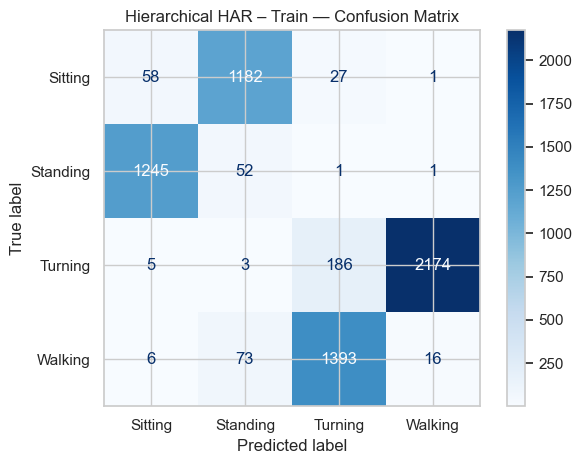


=== Hierarchical HAR – Validation metrics ===
Accuracy : 0.0729
Precision: 0.0734
Recall   : 0.0660
F1-score : 0.0683


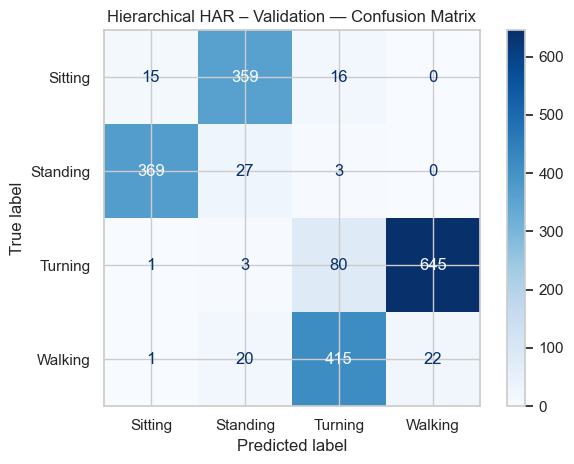


=== Hierarchical HAR – Test metrics ===
Accuracy : 0.0674
Precision: 0.0698
Recall   : 0.0632
F1-score : 0.0652


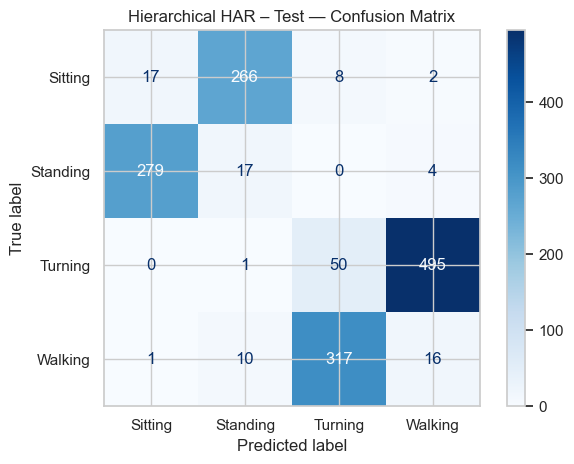

In [ ]:
LABEL_ID_TO_DISPLAY = {
    0: "Standing",
    1: "Sitting",
    2: "Walking",
    3: "Turning",
}
all_class_ids = sorted(LABEL_ID_TO_DISPLAY.keys())

metrics_h_tr = evaluate_model(
    X=Xf_tr,
    y=yf_tr,
    split_name="Hierarchical HAR – Train",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,
    average="macro",
)

metrics_h_val = evaluate_model(
    X=Xf_val,
    y=yf_val,
    split_name="Hierarchical HAR – Validation",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,
    average="macro",
)

metrics_h_te = evaluate_model(
    X=Xf_te,
    y=yf_te,
    split_name="Hierarchical HAR – Test",
    predict_fn=hierarchical_predict_4class,
    label_id_to_display=LABEL_ID_TO_DISPLAY,
    class_labels=all_class_ids,
    average="macro",
)



# 6. Export ONXX